# Mask R-CNN ResNet50-FPN Coffee Disease Model


## Section 1/20 - Execution Contract

This notebook trains a Coffee-specific Mask R-CNN with 4 project classes plus background.

Required outputs:

- Coffee-domain-only vanilla Mask R-CNN baseline checkpoint.
- Coffee-domain-only tuned Mask R-CNN checkpoint.
- mAP@50:95, mAP@50, mIoU, Dice, Macro F1, Weighted F1, Accuracy.
- Precision-recall curves and row-normalized confusion matrix.
- CPU latency in ms/image and throughput in img/s.
- HuggingFace-ready Coffee disease export package with 5 required files.

If a Kaggle GPU or mounted Phase 2 dataset is unavailable, this notebook remains ready for **Run All** on Kaggle and fails early with actionable dataset path diagnostics.


## Section 2/20 - Environment Setup

The environment is expected to be Kaggle with PyTorch, torchvision, OpenCV, scikit-learn, matplotlib, seaborn, pandas, and tqdm. Optional dependencies are handled defensively.


In [1]:
# Global seed is intentionally the first executable logic cell.
SEED = 42

import os
import random

os.environ["PYTHONHASHSEED"] = str(SEED)

import numpy as np

random.seed(SEED)
np.random.seed(SEED)

try:
    import torch
    torch.manual_seed(SEED)
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
except Exception as exc:
    raise RuntimeError(f"Failed to initialize PyTorch reproducibility controls: {exc}") from exc

print(f"Global seed set before pipeline logic: {SEED}")


Global seed set before pipeline logic: 42


In [2]:
from __future__ import annotations

import copy
import gc
import json
import math
import shutil
import time
import warnings
from collections import defaultdict
from dataclasses import asdict, dataclass
from pathlib import Path
from typing import Any, Iterable

import cv2
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from PIL import Image
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score
from torch.utils.data import DataLoader, Dataset, Subset
from torchvision.models.detection import maskrcnn_resnet50_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection.mask_rcnn import MaskRCNNPredictor
from torchvision.transforms import ColorJitter
from torchvision.transforms import functional as TVF
from torchvision.transforms.functional import InterpolationMode
from tqdm.auto import tqdm

try:
    import pycocotools.mask as mask_utils
except Exception:
    mask_utils = None

try:
    from IPython.display import display
except Exception:
    display = None

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)
print("Torch:", torch.__version__)
try:
    import torchvision
    print("Torchvision:", torchvision.__version__)
except Exception:
    pass


Device: cuda
Torch: 2.10.0+cu128
Torchvision: 0.25.0+cu128


## Section 2.5 - Architecture Overview

Mask R-CNN is a two-stage instance segmentation architecture. The ResNet50-FPN backbone extracts multi-scale feature maps; the Region Proposal Network proposes candidate object regions; ROIAlign pools each region into fixed-size features; and task heads predict class labels, bounding-box refinements, and binary masks.

For this Coffee-specific model:

- The backbone is ResNet50 with Feature Pyramid Network.
- COCO-pretrained DEFAULT weights initialize the backbone and detection heads.
- The box classifier and mask classifier are replaced for 5 labels: background plus 4 Coffee disease classes (LeafMiner, PowderyMildew, Rust, AlgalLeafSpot).
- The input resolution is fixed at 256x256 to match Phase 2 preprocessing.
- The model remains vanilla to serve as a strict CNN reference point before comparing against RF-DETR, MobileSAM, and Mask2Former.


## Section 3/20 - Configuration

Edit only this cell when changing Kaggle dataset slug, training budget, or upload behavior.


In [3]:
@dataclass
class NotebookConfig:
    seed: int = 42
    input_size: int = 256
    project_root: Path = Path("/kaggle/working")
    kaggle_input_root: Path = Path("/kaggle/input")
    dataset_slug: str = "ml-vietnam-plant-disease-detection"
    processed_relpath: str = "data/processed"
    local_processed_root: Path = Path("data/processed")
    local_class_names_path: Path = Path("models/class_names.json")
    output_dir: Path = Path("/kaggle/working/mask_rcnn_runs")
    hf_export_dir: Path = Path("/kaggle/working/hf_export")
    num_workers: int = 2
    baseline_epochs: int = 20
    tuning_epochs: int = 10
    batch_size: int = 2
    effective_batch_size: int = 2
    lr: float = 5e-5
    weight_decay: float = 2e-4
    early_stopping_patience: int = 5
    score_threshold: float = 0.5
    max_eval_images: int | None = None
    cpu_benchmark_images: int = 100
    cpu_warmup_images: int = 10
    run_training: bool = True
    run_tuning: bool = True
    resume_from_checkpoint: bool = True
    skip_completed_runs: bool = True
    upload_to_hub: bool = True
    hf_repo_id: str = "trisleex/mask-rcnn-coffee-disease-model"

CFG = NotebookConfig()
CFG.output_dir.mkdir(parents=True, exist_ok=True)
CFG.hf_export_dir.mkdir(parents=True, exist_ok=True)

print(json.dumps({k: str(v) for k, v in asdict(CFG).items()}, indent=2))


{
  "seed": "42",
  "input_size": "256",
  "project_root": "/kaggle/working",
  "kaggle_input_root": "/kaggle/input",
  "dataset_slug": "ml-vietnam-plant-disease-detection",
  "processed_relpath": "data/processed",
  "local_processed_root": "data/processed",
  "local_class_names_path": "models/class_names.json",
  "output_dir": "/kaggle/working/mask_rcnn_runs",
  "hf_export_dir": "/kaggle/working/hf_export",
  "num_workers": "2",
  "baseline_epochs": "20",
  "tuning_epochs": "10",
  "batch_size": "2",
  "effective_batch_size": "2",
  "lr": "5e-05",
  "weight_decay": "0.0002",
  "early_stopping_patience": "5",
  "score_threshold": "0.5",
  "max_eval_images": "None",
  "cpu_benchmark_images": "100",
  "cpu_warmup_images": "10",
  "run_training": "True",
  "run_tuning": "True",
  "resume_from_checkpoint": "True",
  "skip_completed_runs": "True",
  "upload_to_hub": "True",
  "hf_repo_id": "trisleex/mask-rcnn-coffee-disease-model"
}


## Section 4/20 - Class Names And Label Mapping

The source of truth is `models/class_names.json`. The embedded fallback is kept only to keep the Kaggle notebook portable when the repository metadata is not mounted.


In [4]:
EXPECTED_CLASS_NAMES = [
    "LeafMiner",
    "PowderyMildew",
    "Rust",
    "AlgalLeafSpot",
]

CLASS_NAMES = EXPECTED_CLASS_NAMES
NUM_PROJECT_CLASSES = len(CLASS_NAMES)
NUM_MODEL_CLASSES = NUM_PROJECT_CLASSES + 1
MODEL_ID_TO_NAME = {0: "background", **{i + 1: name for i, name in enumerate(CLASS_NAMES)}}
NAME_TO_MODEL_ID = {name: i + 1 for i, name in enumerate(CLASS_NAMES)}
PROJECT_ID_TO_MODEL_ID = {i: i + 1 for i in range(NUM_PROJECT_CLASSES)}

assert NUM_PROJECT_CLASSES == 4
assert NUM_MODEL_CLASSES == 5
print("Using Coffee-specific class names")
print("MODEL_ID_TO_NAME:", MODEL_ID_TO_NAME)


Using Coffee-specific class names
MODEL_ID_TO_NAME: {0: 'background', 1: 'LeafMiner', 2: 'PowderyMildew', 3: 'Rust', 4: 'AlgalLeafSpot'}


## Section 5/20 - Kaggle Paths And Processed Dataset Discovery

The expected default is `/kaggle/input/<dataset-slug>/data/processed`. If the local repository has `data/processed`, the same code can be smoke-tested locally.


In [5]:
def is_processed_root(path: Path) -> bool:
    """Return True when a directory looks like the Phase 2 processed dataset root."""
    return (
        path.exists()
        and (path / "metadata" / "normalization_stats.json").exists()
        and (path / "annotations" / "train.coco.json").exists()
        and (path / "annotations" / "val.coco.json").exists()
        and (path / "annotations" / "test.coco.json").exists()
    )


def resolve_processed_root() -> Path:
    # First try explicit/common layouts.
    candidates = [
        CFG.kaggle_input_root / CFG.dataset_slug / CFG.processed_relpath,
        CFG.kaggle_input_root / CFG.dataset_slug / "processed",
        CFG.kaggle_input_root / CFG.dataset_slug,
        CFG.local_processed_root,
        Path("/kaggle/working/data/processed"),
    ]

    for candidate in candidates:
        if is_processed_root(candidate):
            print("Processed root:", candidate)
            return candidate

    # Then auto-discover across every mounted Kaggle input dataset.
    discovered = []
    if CFG.kaggle_input_root.exists():
        for norm_path in CFG.kaggle_input_root.rglob("normalization_stats.json"):
            candidate = norm_path.parent.parent
            if is_processed_root(candidate):
                discovered.append(candidate)

    if discovered:
        chosen = sorted(discovered, key=lambda p: len(str(p)))[0]
        print("Processed root auto-discovered:", chosen)
        print("All discovered processed roots:")
        for item in discovered:
            print(" -", item)
        return chosen

    checked = "\n".join(str(path) for path in candidates)
    mounted = []
    if CFG.kaggle_input_root.exists():
        mounted = [str(p) for p in CFG.kaggle_input_root.iterdir() if p.is_dir()]
    raise FileNotFoundError(
        "Phase 2 processed dataset is missing or has a different layout.\n"
        "Expected a directory containing:\n"
        "  metadata/normalization_stats.json\n"
        "  annotations/train.coco.json\n"
        "  annotations/val.coco.json\n"
        "  annotations/test.coco.json\n\n"
        f"Checked explicit paths:\n{checked}\n\n"
        f"Mounted /kaggle/input datasets:\n" + "\n".join(mounted)
    )

PROCESSED_ROOT = resolve_processed_root()
METADATA_DIR = PROCESSED_ROOT / "metadata"
NORMALIZATION_PATH_CANDIDATES = [
    METADATA_DIR / "normalization_stats.json",
    PROCESSED_ROOT / "normalization_stats.json",
]


def load_normalization_stats() -> dict[str, list[float]]:
    for path in NORMALIZATION_PATH_CANDIDATES:
        if path.exists():
            stats = json.loads(path.read_text(encoding="utf-8"))
            print("Loaded normalization stats from", path)
            return stats
    raise FileNotFoundError(f"normalization_stats.json not found under {PROCESSED_ROOT}")

NORMALIZATION_STATS = load_normalization_stats()
NORM_MEAN = [float(x) for x in NORMALIZATION_STATS["mean"]]
NORM_STD = [float(x) for x in NORMALIZATION_STATS["std"]]
print("Normalization mean:", NORM_MEAN)
print("Normalization std:", NORM_STD)


Processed root auto-discovered: /kaggle/input/datasets/trixuanle/rice-coffee-leaf-disease-processed/data/processed
All discovered processed roots:
 - /kaggle/input/datasets/trixuanle/rice-coffee-leaf-disease-processed/data/processed
Loaded normalization stats from /kaggle/input/datasets/trixuanle/rice-coffee-leaf-disease-processed/data/processed/metadata/normalization_stats.json
Normalization mean: [0.5469449687686613, 0.5723270663498736, 0.5418894545720082]
Normalization std: [0.32255077868293947, 0.31594286332329463, 0.35688200851415236]


## Section 6/20 - COCO Split Discovery

This cell finds train/validation/test COCO annotations. It supports common Phase 2 layouts with split-specific JSON files. A format mismatch fails early because training against the wrong split policy would invalidate the baseline.


In [6]:
def looks_like_coco(path: Path) -> bool:
    try:
        obj = json.loads(path.read_text(encoding="utf-8"))
    except Exception:
        return False
    return isinstance(obj, dict) and {"images", "annotations", "categories"}.issubset(obj.keys())


def discover_coco_split_files(root: Path) -> dict[str, Path]:
    json_paths = [path for path in root.rglob("*.json") if looks_like_coco(path)]
    if not json_paths:
        raise FileNotFoundError(f"No COCO JSON files found under {root}")

    split_aliases = {
        "train": ["train", "training"],
        "val": ["val", "valid", "validation"],
        "test": ["test", "testing"],
    }
    found: dict[str, Path] = {}
    for split, aliases in split_aliases.items():
        matches = [p for p in json_paths if any(alias in p.stem.lower() or alias in str(p.parent).lower() for alias in aliases)]
        if matches:
            found[split] = sorted(matches, key=lambda p: len(str(p)))[0]

    missing = [split for split in ["train", "val", "test"] if split not in found]
    if missing:
        available = "\n".join(str(path) for path in json_paths)
        raise ValueError(
            "Could not infer all train/val/test COCO split files. "
            f"Missing: {missing}. Available COCO JSON files:\n{available}\n"
            "Expected split-specific filenames or parent directories containing train, val/valid, and test."
        )
    return found

SPLIT_JSONS = discover_coco_split_files(PROCESSED_ROOT)
print("Discovered split annotations:")
for split, path in SPLIT_JSONS.items():
    print(f"  {split}: {path}")


Discovered split annotations:
  train: /kaggle/input/datasets/trixuanle/rice-coffee-leaf-disease-processed/data/processed/annotations/train.coco.json
  val: /kaggle/input/datasets/trixuanle/rice-coffee-leaf-disease-processed/data/processed/annotations/val.coco.json
  test: /kaggle/input/datasets/trixuanle/rice-coffee-leaf-disease-processed/data/processed/annotations/test.coco.json


## Section 7/20 - COCO Utilities And Domain Inference

Domain-level evaluation is mandatory. Domain is inferred from image metadata or file path tokens such as `rice`, `coffee`, `lua`, or `ca_phe`.


In [7]:
RICE_LABELS = {"Healthy", "BrownSpot", "Hispa", "LeafBlast"}
COFFEE_LABELS = {"LeafMiner", "PowderyMildew", "Rust", "AlgalLeafSpot"}


def load_json(path: Path) -> dict[str, Any]:
    return json.loads(path.read_text(encoding="utf-8"))


def infer_domain(record: dict[str, Any], annotations: list[dict[str, Any]] | None = None) -> str:
    fields = [
        str(record.get("file_name", "")),
        str(record.get("domain", "")),
        str(record.get("crop", "")),
        str(record.get("source", "")),
    ]
    text = " ".join(fields).lower()
    if any(token in text for token in ["rice", "lua", "lúa"]):
        return "Rice"
    if any(token in text for token in ["coffee", "cafe", "cà phê", "ca_phe", "caphe"]):
        return "Coffee"
    if annotations:
        labels = {MODEL_ID_TO_NAME.get(int(ann.get("model_label", -1)), "") for ann in annotations}
        if labels and labels <= RICE_LABELS:
            return "Rice"
        if labels and labels <= COFFEE_LABELS:
            return "Coffee"
    return "Unknown"


def xywh_to_xyxy(box: Iterable[float]) -> list[float]:
    x, y, w, h = [float(v) for v in box]
    return [x, y, x + w, y + h]


def mask_to_box(mask: np.ndarray) -> list[float] | None:
    ys, xs = np.where(mask > 0)
    if len(xs) == 0 or len(ys) == 0:
        return None
    return [float(xs.min()), float(ys.min()), float(xs.max() + 1), float(ys.max() + 1)]


def rasterize_segmentation(segmentation: Any, height: int, width: int) -> np.ndarray:
    mask = np.zeros((height, width), dtype=np.uint8)
    if segmentation is None:
        return mask
    if isinstance(segmentation, list):
        for polygon in segmentation:
            arr = np.asarray(polygon, dtype=np.float32).reshape(-1, 2)
            if arr.shape[0] >= 3:
                cv2.fillPoly(mask, [np.round(arr).astype(np.int32)], 1)
        return mask
    if isinstance(segmentation, dict):
        if mask_utils is None:
            raise ImportError("pycocotools is required to decode RLE masks but is not installed.")
        decoded = mask_utils.decode(segmentation)
        if decoded.ndim == 3:
            decoded = decoded.any(axis=2)
        return decoded.astype(np.uint8)
    raise TypeError(f"Unsupported COCO segmentation type: {type(segmentation)}")


def resolve_image_path(file_name: str, annotation_path: Path, processed_root: Path) -> Path:
    candidate_roots = [
        processed_root,
        processed_root / "images",
        annotation_path.parent,
        annotation_path.parent / "images",
        annotation_path.parent.parent / "images",
    ]
    raw = Path(file_name)
    if raw.is_absolute() and raw.exists():
        return raw
    for root in candidate_roots:
        path = root / file_name
        if path.exists():
            return path
    matches = list(processed_root.rglob(raw.name))
    if matches:
        return matches[0]
    raise FileNotFoundError(f"Image file not found for COCO file_name={file_name}")


## Section 8/20 - Dataset Class

The dataset returns exactly the target dictionary expected by torchvision detection models.


In [8]:
class CocoMaskDataset(Dataset):
    def __init__(
        self,
        annotation_path: Path,
        processed_root: Path,
        transforms: Any = None,
        split_name: str = "train",
    ) -> None:
        self.annotation_path = annotation_path
        self.processed_root = processed_root
        self.transforms = transforms
        self.split_name = split_name
        self.coco = load_json(annotation_path)
        self.categories = self.coco["categories"]
        self.cat_id_to_name = {int(cat["id"]): str(cat.get("name", cat["id"])) for cat in self.categories}
        self.cat_id_to_model_id = self._build_category_mapping()
        self.coffee_cat_ids = set()
        for cat in self.categories:
            if cat.get("name", "") in {"LeafMiner", "PowderyMildew", "Rust", "AlgalLeafSpot"}:
                self.coffee_cat_ids.add(int(cat["id"]))
        self.annotations_by_image: dict[int, list[dict[str, Any]]] = defaultdict(list)
        self.invalid_annotation_count = 0
        self.zero_instance_image_count = 0

        for ann in self.coco["annotations"]:
            category_id = int(ann["category_id"])
            if category_id not in self.coffee_cat_ids:
                continue
            model_label = self.cat_id_to_model_id.get(category_id)
            if model_label is None:
                self.invalid_annotation_count += 1
                continue
            ann = copy.deepcopy(ann)
            ann["model_label"] = model_label
            self.annotations_by_image[int(ann["image_id"])].append(ann)

        self.images = []
        for img in self.coco["images"]:
            img_id = int(img["id"])
            if len(self.annotations_by_image.get(img_id, [])) == 0:
                self.zero_instance_image_count += 1
                continue
            self.images.append(img)

    def _build_category_mapping(self) -> dict[int, int]:
        mapping = {}
        for cat in self.categories:
            cat_id = int(cat["id"])
            name = str(cat.get("name", ""))
            if name in NAME_TO_MODEL_ID:
                mapping[cat_id] = NAME_TO_MODEL_ID[name]
        return mapping

    def __len__(self) -> int:
        return len(self.images)

    def __getitem__(self, index: int):
        record = self.images[index]
        image_id = int(record["id"])
        path = resolve_image_path(record["file_name"], self.annotation_path, self.processed_root)
        image = Image.open(path).convert("RGB")
        width, height = image.size
        if (width, height) != (CFG.input_size, CFG.input_size):
            image = image.resize((CFG.input_size, CFG.input_size), Image.BILINEAR)
            width = height = CFG.input_size

        boxes, labels, masks, areas, iscrowd = [], [], [], [], []
        for ann in self.annotations_by_image.get(image_id, []):
            try:
                mask = rasterize_segmentation(ann.get("segmentation"), height, width)
            except Exception:
                mask = np.zeros((height, width), dtype=np.uint8)
            box = mask_to_box(mask)
            if box is None:
                box = xywh_to_xyxy(ann.get("bbox", [0, 0, 0, 0]))
            x1, y1, x2, y2 = box
            if x2 <= x1 or y2 <= y1:
                continue
            boxes.append([x1, y1, x2, y2])
            labels.append(int(ann["model_label"]))
            masks.append(mask)
            areas.append(float(ann.get("area", (x2 - x1) * (y2 - y1))))
            iscrowd.append(int(ann.get("iscrowd", 0)))

        if masks:
            masks_arr = np.stack(masks, axis=0).astype(np.uint8)
        else:
            masks_arr = np.zeros((0, height, width), dtype=np.uint8)

        target = {
            "boxes": torch.as_tensor(boxes, dtype=torch.float32).reshape(-1, 4),
            "labels": torch.as_tensor(labels, dtype=torch.int64),
            "masks": torch.as_tensor(masks_arr, dtype=torch.uint8),
            "image_id": torch.as_tensor([image_id], dtype=torch.int64),
            "area": torch.as_tensor(areas, dtype=torch.float32),
            "iscrowd": torch.as_tensor(iscrowd, dtype=torch.int64),
            "domain": infer_domain(record, self.annotations_by_image.get(image_id, [])),
            "file_name": record.get("file_name", ""),
        }
        if self.transforms is not None:
            image, target = self.transforms(image, target)
        else:
            image = TVF.to_tensor(image)
        return image, target


## Section 9/20 - Data Validation

This section implements the dataset checks from §13: class mapping, image size, boxes, masks, and domain availability.


In [9]:
def summarize_dataset(dataset: CocoMaskDataset) -> dict[str, Any]:
    class_counts = defaultdict(int)
    domain_counts = defaultdict(int)
    invalid_box_count = 0
    empty_mask_count = 0
    for idx in tqdm(range(len(dataset)), desc=f"validate {dataset.split_name}"):
        image, target = dataset[idx]
        if tuple(image.shape[-2:]) != (CFG.input_size, CFG.input_size):
            raise AssertionError(f"Unexpected image size: {image.shape}")
        for label in target["labels"].tolist():
            class_counts[MODEL_ID_TO_NAME[int(label)]] += 1
        domain_counts[target["domain"]] += 1
        boxes = target["boxes"]
        if len(boxes):
            invalid_box_count += int(((boxes[:, 2] <= boxes[:, 0]) | (boxes[:, 3] <= boxes[:, 1])).sum().item())
        if len(target["masks"]):
            empty_mask_count += int((target["masks"].flatten(1).sum(dim=1) == 0).sum().item())
    return {
        "split": dataset.split_name,
        "images": len(dataset),
        "class_counts": dict(class_counts),
        "domain_counts": dict(domain_counts),
        "invalid_box_count": invalid_box_count,
        "empty_mask_count": empty_mask_count,
        "source_invalid_annotation_count": dataset.invalid_annotation_count,
        "zero_instance_image_count": dataset.zero_instance_image_count,
    }

# Temporary no-augmentation datasets for validation.
raw_datasets = {
    split: CocoMaskDataset(path, PROCESSED_ROOT, transforms=None, split_name=split)
    for split, path in SPLIT_JSONS.items()
}

validation_summaries = [summarize_dataset(ds) for ds in raw_datasets.values()]
validation_df = pd.DataFrame(validation_summaries)
display(validation_df) if display else print(validation_df)

for summary in validation_summaries:
    if summary["invalid_box_count"] > 0 or summary["empty_mask_count"] > 0:
        raise AssertionError(f"Dataset validation failed for {summary['split']}: {summary}")
    if summary["domain_counts"].get("Coffee", 0) == 0:
        raise AssertionError(
            f"Coffee model expects all images to be Coffee domain, but split {summary['split']} "
            f"has no Coffee images. Domain counts: {summary['domain_counts']}"
        )
    if summary["domain_counts"].get("Rice", 0) > 0:
        print(f"WARNING: {summary['split']} contains {summary['domain_counts']['Rice']} Rice images (should be 0)")


validate train:   0%|          | 0/2640 [00:00<?, ?it/s]

validate val:   0%|          | 0/569 [00:00<?, ?it/s]

validate test:   0%|          | 0/565 [00:00<?, ?it/s]

,split,images,class_counts,domain_counts,invalid_box_count,empty_mask_count,source_invalid_annotation_count,zero_instance_image_count
0,train,2640,"{'LeafMiner': 835, 'Rust': 965, 'PowderyMildew...",{'Coffee': 2640},0,0,0,2364
1,val,569,"{'Rust': 208, 'AlgalLeafSpot': 141, 'PowderyMi...",{'Coffee': 569},0,0,0,503
2,test,565,"{'AlgalLeafSpot': 139, 'Rust': 208, 'LeafMiner...",{'Coffee': 565},0,0,0,508


## Section 10/20 - Augmentation And Collate Functions

The baseline uses safe affine/intensity augmentation. MixUp and CutMix are implemented as tuning utilities, not as part of the first vanilla run unless explicitly enabled.


In [10]:
class DetectionTransform:
    def __init__(self, train: bool, affine: bool = True, intensity: bool = True, strong: bool = False) -> None:
        self.train = train
        self.affine = affine
        self.intensity = intensity
        if strong:
            self.color_jitter = ColorJitter(brightness=0.25, contrast=0.25, saturation=0.2, hue=0.05)
            self.degrees = 30
            self.translate = (0.08, 0.08)
            self.scale = (0.90, 1.10)
        else:
            # Default augmentation for Coffee (slightly stronger than baseline)
            self.color_jitter = ColorJitter(brightness=0.20, contrast=0.20, saturation=0.15, hue=0.04)
            self.degrees = 20
            self.translate = (0.06, 0.06)
            self.scale = (0.92, 1.08)

    def __call__(self, image: Image.Image, target: dict[str, Any]):
        image_t = TVF.to_tensor(image)
        masks = target["masks"].float()

        if self.train:
            if random.random() < 0.5:
                image_t = TVF.hflip(image_t)
                if len(masks):
                    masks = TVF.hflip(masks)
                boxes = target["boxes"].clone()
                if len(boxes):
                    width = image_t.shape[-1]
                    old_x1 = boxes[:, 0].clone()
                    old_x2 = boxes[:, 2].clone()
                    boxes[:, 0] = width - old_x2
                    boxes[:, 2] = width - old_x1
                    target["boxes"] = boxes

            # Vertical flip is valid for leaf images because there is no fixed canonical orientation.
            if random.random() < 0.5:
                image_t = TVF.vflip(image_t)
                if len(masks):
                    masks = TVF.vflip(masks)
                boxes = target["boxes"].clone()
                if len(boxes):
                    height = image_t.shape[-2]
                    old_y1 = boxes[:, 1].clone()
                    old_y2 = boxes[:, 3].clone()
                    boxes[:, 1] = height - old_y2
                    boxes[:, 3] = height - old_y1
                    target["boxes"] = boxes

            if self.affine and random.random() < 0.5:
                angle = random.uniform(-self.degrees, self.degrees)
                max_dx = self.translate[0] * image_t.shape[-1]
                max_dy = self.translate[1] * image_t.shape[-2]
                translations = (int(random.uniform(-max_dx, max_dx)), int(random.uniform(-max_dy, max_dy)))
                scale = random.uniform(self.scale[0], self.scale[1])
                image_t = TVF.affine(
                    image_t,
                    angle=angle,
                    translate=translations,
                    scale=scale,
                    shear=[0.0, 0.0],
                    interpolation=InterpolationMode.BILINEAR,
                    fill=0,
                )
                if len(masks):
                    masks = TVF.affine(
                        masks,
                        angle=angle,
                        translate=translations,
                        scale=scale,
                        shear=[0.0, 0.0],
                        interpolation=InterpolationMode.NEAREST,
                        fill=0,
                    )
                    target = recompute_targets_from_masks(target, masks)

            if self.intensity and random.random() < 0.7:
                image_t = self.color_jitter(image_t)

        target["masks"] = target["masks"].to(torch.uint8)
        return image_t, target


def recompute_targets_from_masks(target: dict[str, Any], masks: torch.Tensor) -> dict[str, Any]:
    new_boxes, keep = [], []
    masks_np = (masks.detach().cpu().numpy() > 0.5).astype(np.uint8)
    for idx, mask in enumerate(masks_np):
        box = mask_to_box(mask)
        if box is not None:
            new_boxes.append(box)
            keep.append(idx)
    if not keep:
        target["boxes"] = torch.zeros((0, 4), dtype=torch.float32)
        target["labels"] = torch.zeros((0,), dtype=torch.int64)
        target["masks"] = torch.zeros((0, CFG.input_size, CFG.input_size), dtype=torch.uint8)
        target["area"] = torch.zeros((0,), dtype=torch.float32)
        target["iscrowd"] = torch.zeros((0,), dtype=torch.int64)
        target["domain"] = target.get("domain", "Unknown")
        target["file_name"] = target.get("file_name", "")
        return target
    keep_t = torch.as_tensor(keep, dtype=torch.long)
    target["boxes"] = torch.as_tensor(new_boxes, dtype=torch.float32)
    target["labels"] = target["labels"][keep_t]
    target["masks"] = (masks[keep_t] > 0.5).to(torch.uint8)
    target["area"] = target["masks"].flatten(1).sum(dim=1).float()
    target["iscrowd"] = target["iscrowd"][keep_t]
    return target


def collate_fn(batch):
    images, targets = zip(*batch)
    return list(images), list(targets)


def cutmix_batch(images, targets, alpha: float = 1.0, p: float = 0.5):
    if random.random() > p or len(images) < 2:
        return images, targets
    lam = np.random.beta(alpha, alpha)
    h, w = images[0].shape[-2:]
    cut_ratio = math.sqrt(1.0 - lam)
    cut_w, cut_h = int(w * cut_ratio), int(h * cut_ratio)
    cx, cy = np.random.randint(w), np.random.randint(h)
    x1, x2 = np.clip([cx - cut_w // 2, cx + cut_w // 2], 0, w)
    y1, y2 = np.clip([cy - cut_h // 2, cy + cut_h // 2], 0, h)
    perm = torch.randperm(len(images)).tolist()
    mixed_images, mixed_targets = [], []
    patch_mask = torch.zeros((h, w), dtype=torch.bool)
    patch_mask[y1:y2, x1:x2] = True
    for i, j in enumerate(perm):
        img = images[i].clone()
        img[:, y1:y2, x1:x2] = images[j][:, y1:y2, x1:x2]
        tgt_i = copy.deepcopy(targets[i])
        tgt_j = copy.deepcopy(targets[j])
        if len(tgt_j["masks"]):
            pasted_masks = tgt_j["masks"].clone()
            pasted_masks[:, ~patch_mask] = 0
            merged = {
                "boxes": torch.cat([tgt_i["boxes"], tgt_j["boxes"]], dim=0),
                "labels": torch.cat([tgt_i["labels"], tgt_j["labels"]], dim=0),
                "masks": torch.cat([tgt_i["masks"], pasted_masks], dim=0),
                "image_id": tgt_i["image_id"],
                "area": torch.cat([tgt_i["area"], pasted_masks.flatten(1).sum(dim=1).float()], dim=0),
                "iscrowd": torch.cat([tgt_i["iscrowd"], tgt_j["iscrowd"]], dim=0),
                "domain": tgt_i.get("domain", "Unknown"),
                "file_name": tgt_i.get("file_name", ""),
            }
            merged = recompute_targets_from_masks(merged, merged["masks"].float())
            mixed_targets.append(merged)
        else:
            mixed_targets.append(tgt_i)
        mixed_images.append(img)
    return mixed_images, mixed_targets


def mixup_batch(images, targets, alpha: float = 0.4, p: float = 0.3):
    if random.random() > p or len(images) < 2:
        return images, targets
    lam = float(np.random.beta(alpha, alpha))
    perm = torch.randperm(len(images)).tolist()
    mixed_images, mixed_targets = [], []
    for i, j in enumerate(perm):
        img = lam * images[i] + (1.0 - lam) * images[j]
        tgt_i = copy.deepcopy(targets[i])
        tgt_j = copy.deepcopy(targets[j])
        merged = {
            "boxes": torch.cat([tgt_i["boxes"], tgt_j["boxes"]], dim=0),
            "labels": torch.cat([tgt_i["labels"], tgt_j["labels"]], dim=0),
            "masks": torch.cat([tgt_i["masks"], tgt_j["masks"]], dim=0),
            "image_id": tgt_i["image_id"],
            "area": torch.cat([tgt_i["area"], tgt_j["area"]], dim=0),
            "iscrowd": torch.cat([tgt_i["iscrowd"], tgt_j["iscrowd"]], dim=0),
            "domain": tgt_i.get("domain", "Unknown"),
            "file_name": tgt_i.get("file_name", ""),
        }
        mixed_images.append(img)
        mixed_targets.append(merged)
    return mixed_images, mixed_targets


## Section 11/20 - DataLoaders

The full training DataLoaders use the validated COCO splits. Optional debug subsets can be enabled by setting `CFG.max_eval_images` or wrapping datasets with `Subset`.


In [11]:
train_transform = DetectionTransform(train=True, affine=True, intensity=True, strong=False)
eval_transform = DetectionTransform(train=False, affine=False, intensity=False)

train_dataset = CocoMaskDataset(SPLIT_JSONS["train"], PROCESSED_ROOT, transforms=train_transform, split_name="train")
val_dataset = CocoMaskDataset(SPLIT_JSONS["val"], PROCESSED_ROOT, transforms=eval_transform, split_name="val")
test_dataset = CocoMaskDataset(SPLIT_JSONS["test"], PROCESSED_ROOT, transforms=eval_transform, split_name="test")

train_loader = DataLoader(
    train_dataset,
    batch_size=CFG.batch_size,
    shuffle=True,
    num_workers=CFG.num_workers,
    pin_memory=torch.cuda.is_available(),
    collate_fn=collate_fn,
)
val_loader = DataLoader(
    val_dataset,
    batch_size=1,
    shuffle=False,
    num_workers=CFG.num_workers,
    pin_memory=torch.cuda.is_available(),
    collate_fn=collate_fn,
)
test_loader = DataLoader(
    test_dataset,
    batch_size=1,
    shuffle=False,
    num_workers=CFG.num_workers,
    pin_memory=torch.cuda.is_available(),
    collate_fn=collate_fn,
)

print(f"Train/Val/Test images: {len(train_dataset)} / {len(val_dataset)} / {len(test_dataset)}")


Train/Val/Test images: 2640 / 569 / 565


## Section 12/20 - Model Builder

The model uses torchvision Mask R-CNN ResNet50-FPN with DEFAULT COCO-pretrained weights. The model transform is configured for 256x256 images and Phase 2 normalization statistics.


In [12]:
def build_mask_rcnn_model(lr: float = CFG.lr) -> torch.nn.Module:
    model = maskrcnn_resnet50_fpn(
        weights="DEFAULT",
        min_size=CFG.input_size,
        max_size=CFG.input_size,
        image_mean=NORM_MEAN,
        image_std=NORM_STD,
    )
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, NUM_MODEL_CLASSES)

    in_features_mask = model.roi_heads.mask_predictor.conv5_mask.in_channels
    hidden_layer = 256
    model.roi_heads.mask_predictor = MaskRCNNPredictor(in_features_mask, hidden_layer, NUM_MODEL_CLASSES)
    return model


def make_optimizer(model: torch.nn.Module, lr: float, weight_decay: float):
    params = [p for p in model.parameters() if p.requires_grad]
    return torch.optim.AdamW(params, lr=lr, weight_decay=weight_decay)


def make_scheduler(optimizer):
    return torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=2)

model = build_mask_rcnn_model().to(DEVICE)
print(type(model).__name__, "ready with", NUM_MODEL_CLASSES, "classes")
del model
gc.collect()
torch.cuda.empty_cache() if torch.cuda.is_available() else None


def load_model_from_checkpoint(path: Path, map_location=DEVICE):
    """Load a saved Mask R-CNN checkpoint. Kept near the model builder so later sections can run independently."""
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f"Checkpoint not found: {path}")
    checkpoint = torch.load(path, map_location=map_location)
    model = build_mask_rcnn_model().to(map_location)
    model.load_state_dict(checkpoint["model_state_dict"])
    model.eval()
    return model, checkpoint


def checkpoint_paths(run_name: str) -> tuple[Path, Path, Path]:
    return (
        CFG.output_dir / f"{run_name}_best.pth",
        CFG.output_dir / f"{run_name}_last.pth",
        CFG.output_dir / f"{run_name}_history.csv",
    )


def load_history_if_exists(path: Path) -> list[dict[str, Any]]:
    if path.exists():
        return pd.read_csv(path).to_dict("records")
    return []


def checkpoint_metric(path: Path) -> float:
    if not Path(path).exists():
        return float("-inf")
    try:
        checkpoint = torch.load(path, map_location="cpu")
        return float(checkpoint.get("best_metric", float("-inf")))
    except Exception as exc:
        print(f"Could not read checkpoint metric from {path}: {exc}")
        return float("-inf")


def resolve_tuned_best_path() -> Path:
    """Find the best tuned checkpoint after a kernel reset or partial rerun."""
    if "tuned_best_path" in globals() and Path(tuned_best_path).exists():
        return Path(tuned_best_path)

    summary_path = CFG.output_dir / "tuning_results.csv"
    if summary_path.exists():
        summary = pd.read_csv(summary_path).sort_values("best_val_mAP@50:95", ascending=False)
        for candidate in summary.get("best_path", []):
            candidate_path = Path(candidate)
            if candidate_path.exists():
                print("Resolved tuned checkpoint from tuning_results.csv:", candidate_path)
                return candidate_path

    candidates = sorted(CFG.output_dir.glob("coffee_tuned*_best.pth"), key=checkpoint_metric, reverse=True)
    if candidates:
        print("Resolved tuned checkpoint from *_best.pth files:", candidates[0])
        return candidates[0]

    baseline_candidate = CFG.output_dir / "mask_rcnn_coffee_baseline_best.pth"
    if baseline_candidate.exists():
        print("No tuned checkpoint found; falling back to baseline checkpoint:", baseline_candidate)
        return baseline_candidate

    raise FileNotFoundError(
        f"No usable checkpoint found in {CFG.output_dir}. Run Section 15/18 first or attach Kaggle working outputs."
    )


Downloading: "https://download.pytorch.org/models/maskrcnn_resnet50_fpn_coco-bf2d0c1e.pth" to /root/.cache/torch/hub/checkpoints/maskrcnn_resnet50_fpn_coco-bf2d0c1e.pth


100%|██████████| 170M/170M [00:01<00:00, 172MB/s]


MaskRCNN ready with 5 classes


## Section 13/20 - Metric Implementations

This section implements mask IoU, Dice, AP/mAP, Macro F1, Weighted F1, Accuracy, PR curves, confusion matrix, and per-domain slicing.


In [13]:
def move_targets_to_device(targets, device):
    moved = []
    for target in targets:
        moved_target = {}
        for key, value in target.items():
            moved_target[key] = value.to(device) if torch.is_tensor(value) else value
        moved.append(moved_target)
    return moved


def mask_iou(mask_a: np.ndarray, mask_b: np.ndarray) -> float:
    a = mask_a.astype(bool)
    b = mask_b.astype(bool)
    inter = np.logical_and(a, b).sum()
    union = np.logical_or(a, b).sum()
    return float(inter / union) if union > 0 else 0.0


def dice_score(mask_a: np.ndarray, mask_b: np.ndarray) -> float:
    a = mask_a.astype(bool)
    b = mask_b.astype(bool)
    denom = a.sum() + b.sum()
    return float(2 * np.logical_and(a, b).sum() / denom) if denom > 0 else 0.0


def tensor_target_to_instances(target: dict[str, Any]) -> list[dict[str, Any]]:
    instances = []
    for idx in range(len(target["labels"])):
        instances.append({
            "label": int(target["labels"][idx].detach().cpu().item()),
            "mask": target["masks"][idx].detach().cpu().numpy().astype(np.uint8),
            "score": 1.0,
        })
    return instances


def tensor_output_to_instances(output: dict[str, torch.Tensor], score_threshold: float) -> list[dict[str, Any]]:
    instances = []
    scores = output.get("scores", torch.empty(0)).detach().cpu()
    labels = output.get("labels", torch.empty(0)).detach().cpu()
    masks = output.get("masks", torch.empty(0)).detach().cpu()
    for idx in range(len(scores)):
        score = float(scores[idx].item())
        if score < score_threshold:
            continue
        mask = (masks[idx, 0].numpy() >= 0.5).astype(np.uint8)
        instances.append({"label": int(labels[idx].item()), "mask": mask, "score": score})
    return instances


def collect_predictions(model, loader, score_threshold: float, max_images: int | None = None):
    model.eval()
    records = []
    image_count = 0
    with torch.no_grad():
        for images, targets in tqdm(loader, desc="collect predictions"):
            if max_images is not None and image_count >= max_images:
                break
            images_device = [img.to(DEVICE) for img in images]
            outputs = model(images_device)
            for image, target, output in zip(images, targets, outputs):
                if max_images is not None and image_count >= max_images:
                    break
                image_id = int(target["image_id"].item())
                records.append({
                    "image_id": image_id,
                    "domain": target.get("domain", "Unknown"),
                    "file_name": target.get("file_name", ""),
                    "image": image.detach().cpu(),
                    "gt": tensor_target_to_instances(target),
                    "pred": tensor_output_to_instances(output, score_threshold),
                })
                image_count += 1
    return records


def average_precision(recalls: np.ndarray, precisions: np.ndarray) -> float:
    if len(recalls) == 0:
        return float("nan")
    mrec = np.concatenate(([0.0], recalls, [1.0]))
    mpre = np.concatenate(([0.0], precisions, [0.0]))
    for i in range(len(mpre) - 1, 0, -1):
        mpre[i - 1] = max(mpre[i - 1], mpre[i])
    indices = np.where(mrec[1:] != mrec[:-1])[0]
    return float(np.sum((mrec[indices + 1] - mrec[indices]) * mpre[indices + 1]))


def ap_for_class(records, class_id: int, iou_threshold: float):
    gt_by_image = defaultdict(list)
    pred_rows = []
    for rec in records:
        image_id = rec["image_id"]
        for gt in rec["gt"]:
            if gt["label"] == class_id:
                gt_by_image[image_id].append(gt)
        for pred in rec["pred"]:
            if pred["label"] == class_id:
                pred_rows.append((image_id, pred["score"], pred))
    total_gt = sum(len(items) for items in gt_by_image.values())
    if total_gt == 0:
        return float("nan"), np.array([]), np.array([])
    pred_rows.sort(key=lambda row: row[1], reverse=True)
    matched = defaultdict(set)
    tp, fp = [], []
    for image_id, _, pred in pred_rows:
        best_iou, best_idx = 0.0, None
        for gt_idx, gt in enumerate(gt_by_image.get(image_id, [])):
            if gt_idx in matched[image_id]:
                continue
            iou = mask_iou(pred["mask"], gt["mask"])
            if iou > best_iou:
                best_iou, best_idx = iou, gt_idx
        if best_iou >= iou_threshold and best_idx is not None:
            matched[image_id].add(best_idx)
            tp.append(1.0)
            fp.append(0.0)
        else:
            tp.append(0.0)
            fp.append(1.0)
    if not tp:
        return 0.0, np.array([0.0]), np.array([0.0])
    tp = np.cumsum(tp)
    fp = np.cumsum(fp)
    recalls = tp / max(total_gt, 1)
    precisions = tp / np.maximum(tp + fp, 1e-12)
    return average_precision(recalls, precisions), recalls, precisions


def compute_map(records, iou_thresholds=None):
    if iou_thresholds is None:
        iou_thresholds = np.round(np.arange(0.50, 0.96, 0.05), 2)
    rows = []
    for thr in iou_thresholds:
        for class_id in range(1, NUM_MODEL_CLASSES):
            ap, recalls, precisions = ap_for_class(records, class_id, float(thr))
            rows.append({
                "iou_threshold": float(thr),
                "class_id": class_id,
                "class_name": MODEL_ID_TO_NAME[class_id],
                "ap": ap,
                "recalls": recalls,
                "precisions": precisions,
            })
    ap_df = pd.DataFrame(rows)
    map_5095 = float(ap_df["ap"].dropna().mean())
    map_50 = float(ap_df.loc[ap_df["iou_threshold"] == 0.5, "ap"].dropna().mean())
    return {"mAP@50:95": map_5095, "mAP@50": map_50, "ap_table": ap_df}


def build_confusion(records, iou_threshold: float = 0.5):
    y_true, y_pred = [], []
    iou_values, dice_values = [], []
    for rec in records:
        preds = sorted(rec["pred"], key=lambda item: item["score"], reverse=True)
        used_preds = set()
        for gt in rec["gt"]:
            best_iou, best_idx = 0.0, None
            for pred_idx, pred in enumerate(preds):
                if pred_idx in used_preds:
                    continue
                iou = mask_iou(gt["mask"], pred["mask"])
                if iou > best_iou:
                    best_iou, best_idx = iou, pred_idx
            y_true.append(gt["label"])
            if best_iou >= iou_threshold and best_idx is not None:
                pred = preds[best_idx]
                used_preds.add(best_idx)
                y_pred.append(pred["label"])
                iou_values.append(best_iou)
                dice_values.append(dice_score(gt["mask"], pred["mask"]))
            else:
                y_pred.append(0)
                iou_values.append(0.0)
                dice_values.append(0.0)
        for pred_idx, pred in enumerate(preds):
            if pred_idx not in used_preds:
                y_true.append(0)
                y_pred.append(pred["label"])
    labels = list(range(NUM_MODEL_CLASSES))
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    row_sums = cm.sum(axis=1, keepdims=True)
    cm_norm = np.divide(cm, row_sums, out=np.zeros_like(cm, dtype=float), where=row_sums != 0)
    metrics = {
        "Macro F1": f1_score(y_true, y_pred, labels=labels, average="macro", zero_division=0),
        "Weighted F1": f1_score(y_true, y_pred, labels=labels, average="weighted", zero_division=0),
        "Accuracy": accuracy_score(y_true, y_pred),
        "mIoU": float(np.mean(iou_values)) if iou_values else 0.0,
        "Dice": float(np.mean(dice_values)) if dice_values else 0.0,
    }
    return metrics, cm, cm_norm, y_true, y_pred


def evaluate_records(records, split_name: str):
    map_result = compute_map(records)
    cls_metrics, cm, cm_norm, y_true, y_pred = build_confusion(records)
    metrics = {"split": split_name, **{k: v for k, v in map_result.items() if k != "ap_table"}, **cls_metrics}
    return metrics, map_result["ap_table"], cm, cm_norm


def evaluate_by_domain(records, split_name: str):
    metrics, _, _, _ = evaluate_records(records, f"{split_name}_coffee")
    metrics["domain"] = "Coffee"
    return pd.DataFrame([metrics])


## Section 14/20 - Plotting Utilities

Visual outputs include prediction-vs-ground-truth panels, PR curves, and a row-normalized confusion matrix heat map.


In [14]:
def denorm_for_display(image_t: torch.Tensor) -> np.ndarray:
    arr = image_t.detach().cpu().permute(1, 2, 0).numpy()
    return np.clip(arr, 0, 1)


def overlay_mask(image: np.ndarray, mask: np.ndarray, color=(1.0, 0.0, 0.0), alpha=0.35) -> np.ndarray:
    out = image.copy()
    m = mask.astype(bool)
    out[m] = (1 - alpha) * out[m] + alpha * np.asarray(color)
    return out


def plot_prediction_examples(records, n: int = 10, title: str = "Predictions vs Ground Truth"):
    sample = records[: min(n, len(records))]
    fig, axes = plt.subplots(len(sample), 3, figsize=(12, 4 * len(sample)))
    if len(sample) == 1:
        axes = np.expand_dims(axes, 0)
    for row, rec in enumerate(sample):
        image = denorm_for_display(rec["image"])
        gt_overlay = image.copy()
        pred_overlay = image.copy()
        for gt in rec["gt"]:
            gt_overlay = overlay_mask(gt_overlay, gt["mask"], color=(0, 1, 0), alpha=0.35)
        for pred in rec["pred"]:
            pred_overlay = overlay_mask(pred_overlay, pred["mask"], color=(1, 0, 0), alpha=0.35)
        axes[row, 0].imshow(image)
        axes[row, 0].set_title(f"Image {rec['image_id']} ({rec['domain']})")
        axes[row, 1].imshow(gt_overlay)
        axes[row, 1].set_title("Ground truth")
        axes[row, 2].imshow(pred_overlay)
        pred_labels = ", ".join(f"{MODEL_ID_TO_NAME[p['label']]}:{p['score']:.2f}" for p in rec["pred"][:3])
        axes[row, 2].set_title("Predictions " + pred_labels)
        for col in range(3):
            axes[row, col].axis("off")
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


def plot_confusion_heatmap(cm_norm: np.ndarray, title: str):
    labels = [MODEL_ID_TO_NAME[i] for i in range(NUM_MODEL_CLASSES)]
    plt.figure(figsize=(11, 9))
    sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues", xticklabels=labels, yticklabels=labels)
    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    plt.title(title + " - row-normalized confusion matrix")
    plt.tight_layout()
    plt.show()


def plot_pr_curves(ap_table: pd.DataFrame, title: str, iou_threshold: float = 0.5):
    plt.figure(figsize=(10, 7))
    sub = ap_table[ap_table["iou_threshold"] == iou_threshold]
    for _, row in sub.iterrows():
        recalls = row["recalls"]
        precisions = row["precisions"]
        if len(recalls) == 0:
            continue
        plt.plot(recalls, precisions, label=f"{row['class_name']} AP={row['ap']:.3f}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(title + f" PR curves @ IoU {iou_threshold:.2f}")
    plt.legend(loc="lower left", fontsize=8)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


## Section 15/20 - Baseline Training

This is the strict vanilla baseline. It uses the fixed architecture, baseline-safe augmentation, and validation mAP@50:95 checkpoint selection.


In [15]:
def save_checkpoint(path: Path, model, optimizer, scheduler, epoch: int, best_metric: float, config: dict[str, Any], metrics: dict[str, Any]):
    payload = {
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict() if optimizer else None,
        "scheduler_state_dict": scheduler.state_dict() if scheduler else None,
        "epoch": epoch,
        "best_metric": best_metric,
        "class_names": CLASS_NAMES,
        "model_id_to_name": MODEL_ID_TO_NAME,
        "rice_labels": list(RICE_LABELS),
        "coffee_labels": list(COFFEE_LABELS),
        "input_size": [CFG.input_size, CFG.input_size],
        "normalization_stats": NORMALIZATION_STATS,
        "seed": CFG.seed,
        "config": config,
        "metrics": metrics,
    }
    torch.save(payload, path)


def train_one_epoch(model, optimizer, loader, epoch: int, grad_accum_steps: int = 1, cutmix: bool = False, mixup: bool = False):
    model.train()
    loss_sums = defaultdict(float)
    optimizer.zero_grad(set_to_none=True)
    pbar = tqdm(loader, desc=f"epoch {epoch}")
    for step, (images, targets) in enumerate(pbar, start=1):
        if cutmix:
            images, targets = cutmix_batch(images, targets, alpha=1.0, p=0.5)
        if mixup:
            images, targets = mixup_batch(images, targets, alpha=0.4, p=0.25)
        images = [img.to(DEVICE) for img in images]
        targets = move_targets_to_device(targets, DEVICE)
        loss_dict = model(images, targets)
        loss = sum(loss for loss in loss_dict.values()) / grad_accum_steps
        if not torch.isfinite(loss):
            raise FloatingPointError(f"Non-finite loss at epoch {epoch}, step {step}: {loss_dict}")
        loss.backward()
        if step % grad_accum_steps == 0:
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
            optimizer.step()
            optimizer.zero_grad(set_to_none=True)
        for name, value in loss_dict.items():
            loss_sums[name] += float(value.detach().cpu().item())
        pbar.set_postfix(total=sum(loss_sums.values()) / step)
    return {name: value / max(len(loader), 1) for name, value in loss_sums.items()}


def fit_model(
    run_name: str,
    train_loader,
    val_loader,
    epochs: int,
    lr: float,
    weight_decay: float,
    grad_accum_steps: int = 1,
    cutmix: bool = False,
    mixup: bool = False,
    freeze_backbone_epochs: int = 0,
):
    model = build_mask_rcnn_model().to(DEVICE)
    if freeze_backbone_epochs > 0:
        for param in model.backbone.parameters():
            param.requires_grad = False
        print(f"Backbone frozen for first {freeze_backbone_epochs} epochs")
    optimizer = make_optimizer(model, lr=lr, weight_decay=weight_decay)
    scheduler = make_scheduler(optimizer)
    best_metric = -1.0
    best_path, last_path, history_path = checkpoint_paths(run_name)
    history = load_history_if_exists(history_path)
    patience_left = CFG.early_stopping_patience
    run_config = {
        "run_name": run_name,
        "epochs": epochs,
        "lr": lr,
        "weight_decay": weight_decay,
        "grad_accum_steps": grad_accum_steps,
        "cutmix": cutmix,
        "mixup": mixup,
        "freeze_backbone_epochs": freeze_backbone_epochs,
        "seed": CFG.seed,
    }

    if CFG.skip_completed_runs and best_path.exists() and history_path.exists():
        history_df = pd.read_csv(history_path)
        print(f"Using existing completed checkpoint for {run_name}: {best_path}")
        return best_path, history_df

    start_epoch = 1
    if CFG.resume_from_checkpoint and last_path.exists():
        print(f"Resuming {run_name} from checkpoint: {last_path}")
        checkpoint = torch.load(last_path, map_location=DEVICE)
        model.load_state_dict(checkpoint["model_state_dict"])
        if checkpoint.get("optimizer_state_dict"):
            try:
                optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
            except ValueError as exc:
                print(f"Optimizer state could not be restored; continuing with a fresh optimizer: {exc}")
        if checkpoint.get("scheduler_state_dict"):
            try:
                scheduler.load_state_dict(checkpoint["scheduler_state_dict"])
            except Exception as exc:
                print(f"Scheduler state could not be restored; continuing with a fresh scheduler: {exc}")
        best_metric = float(checkpoint.get("best_metric", checkpoint_metric(best_path)))
        start_epoch = int(checkpoint.get("epoch", 0)) + 1
        print(f"Resume state: start_epoch={start_epoch}, best_mAP@50:95={best_metric:.4f}")

    if start_epoch > epochs:
        history_df = pd.DataFrame(history)
        if history_df.empty and history_path.exists():
            history_df = pd.read_csv(history_path)
        print(f"{run_name} already reached requested epochs; using {best_path}")
        return best_path, history_df

    for epoch in range(start_epoch, epochs + 1):
        if freeze_backbone_epochs > 0 and epoch == freeze_backbone_epochs + 1:
            for param in model.backbone.parameters():
                param.requires_grad = True
            optimizer = make_optimizer(model, lr=lr * 0.1, weight_decay=weight_decay)
            scheduler = make_scheduler(optimizer)
            print(f"Backbone unfrozen at epoch {epoch}, lr reduced to {lr * 0.1:.2e}")
        train_losses = train_one_epoch(model, optimizer, train_loader, epoch, grad_accum_steps, cutmix=cutmix, mixup=mixup)
        val_records = collect_predictions(model, val_loader, CFG.score_threshold, max_images=CFG.max_eval_images)
        val_metrics, _, _, _ = evaluate_records(val_records, "val")
        scheduler.step(val_metrics["mAP@50:95"])
        row = {"epoch": epoch, **{f"train_{k}": v for k, v in train_losses.items()}, **val_metrics}
        history.append(row)
        save_checkpoint(last_path, model, optimizer, scheduler, epoch, best_metric, run_config, row)
        if val_metrics["mAP@50:95"] > best_metric:
            best_metric = val_metrics["mAP@50:95"]
            patience_left = CFG.early_stopping_patience
            save_checkpoint(best_path, model, optimizer, scheduler, epoch, best_metric, run_config, row)
            print(f"New best {run_name}: epoch={epoch}, mAP@50:95={best_metric:.4f}")
        else:
            patience_left -= 1
            if patience_left <= 0:
                print(f"Early stopping {run_name} at epoch {epoch}")
                break
    history_df = pd.DataFrame(history)
    history_df.to_csv(history_path, index=False)
    return best_path, history_df

if CFG.run_training:
    baseline_best_path, baseline_history = fit_model(
        run_name="mask_rcnn_coffee_baseline",
        train_loader=train_loader,
        val_loader=val_loader,
        epochs=CFG.baseline_epochs,
        lr=CFG.lr,
        weight_decay=CFG.weight_decay,
        grad_accum_steps=max(1, CFG.effective_batch_size // CFG.batch_size),
        cutmix=False,
        mixup=False,
    )
else:
    baseline_best_path = CFG.output_dir / "mask_rcnn_coffee_baseline_best.pth"
    baseline_history = pd.DataFrame()
    print("Training skipped by CFG.run_training=False")


epoch 1:   0%|          | 0/1320 [00:00<?, ?it/s]

collect predictions:   0%|          | 0/569 [00:00<?, ?it/s]

New best mask_rcnn_coffee_baseline: epoch=1, mAP@50:95=0.1764


epoch 2:   0%|          | 0/1320 [00:00<?, ?it/s]

collect predictions:   0%|          | 0/569 [00:00<?, ?it/s]

...

epoch 6:   0%|          | 0/1320 [00:00<?, ?it/s]

collect predictions:   0%|          | 0/569 [00:00<?, ?it/s]

epoch 7:   0%|          | 0/1320 [00:00<?, ?it/s]

collect predictions:   0%|          | 0/569 [00:00<?, ?it/s]

Early stopping mask_rcnn_coffee_baseline at epoch 7


## Section 16/20 - Baseline Validation And Test Evaluation

The validation set selects the best checkpoint. The locked test set is used only after the baseline checkpoint exists.


collect predictions:   0%|          | 0/569 [00:00<?, ?it/s]

collect predictions:   0%|          | 0/565 [00:00<?, ?it/s]

Baseline validation metrics


,split,mAP@50:95,mAP@50,Macro F1,Weighted F1,Accuracy,mIoU,Dice
0,val,0.393039,0.62563,0.498469,0.507111,0.546575,0.732102,0.797069


Baseline test metrics


,split,mAP@50:95,mAP@50,Macro F1,Weighted F1,Accuracy,mIoU,Dice
0,test,0.422597,0.680218,0.539717,0.534493,0.571627,0.726384,0.792677


Baseline per-domain test metrics


,split,mAP@50:95,mAP@50,Macro F1,Weighted F1,Accuracy,mIoU,Dice,domain
0,test_coffee,0.422597,0.680218,0.539717,0.534493,0.571627,0.726384,0.792677,Coffee


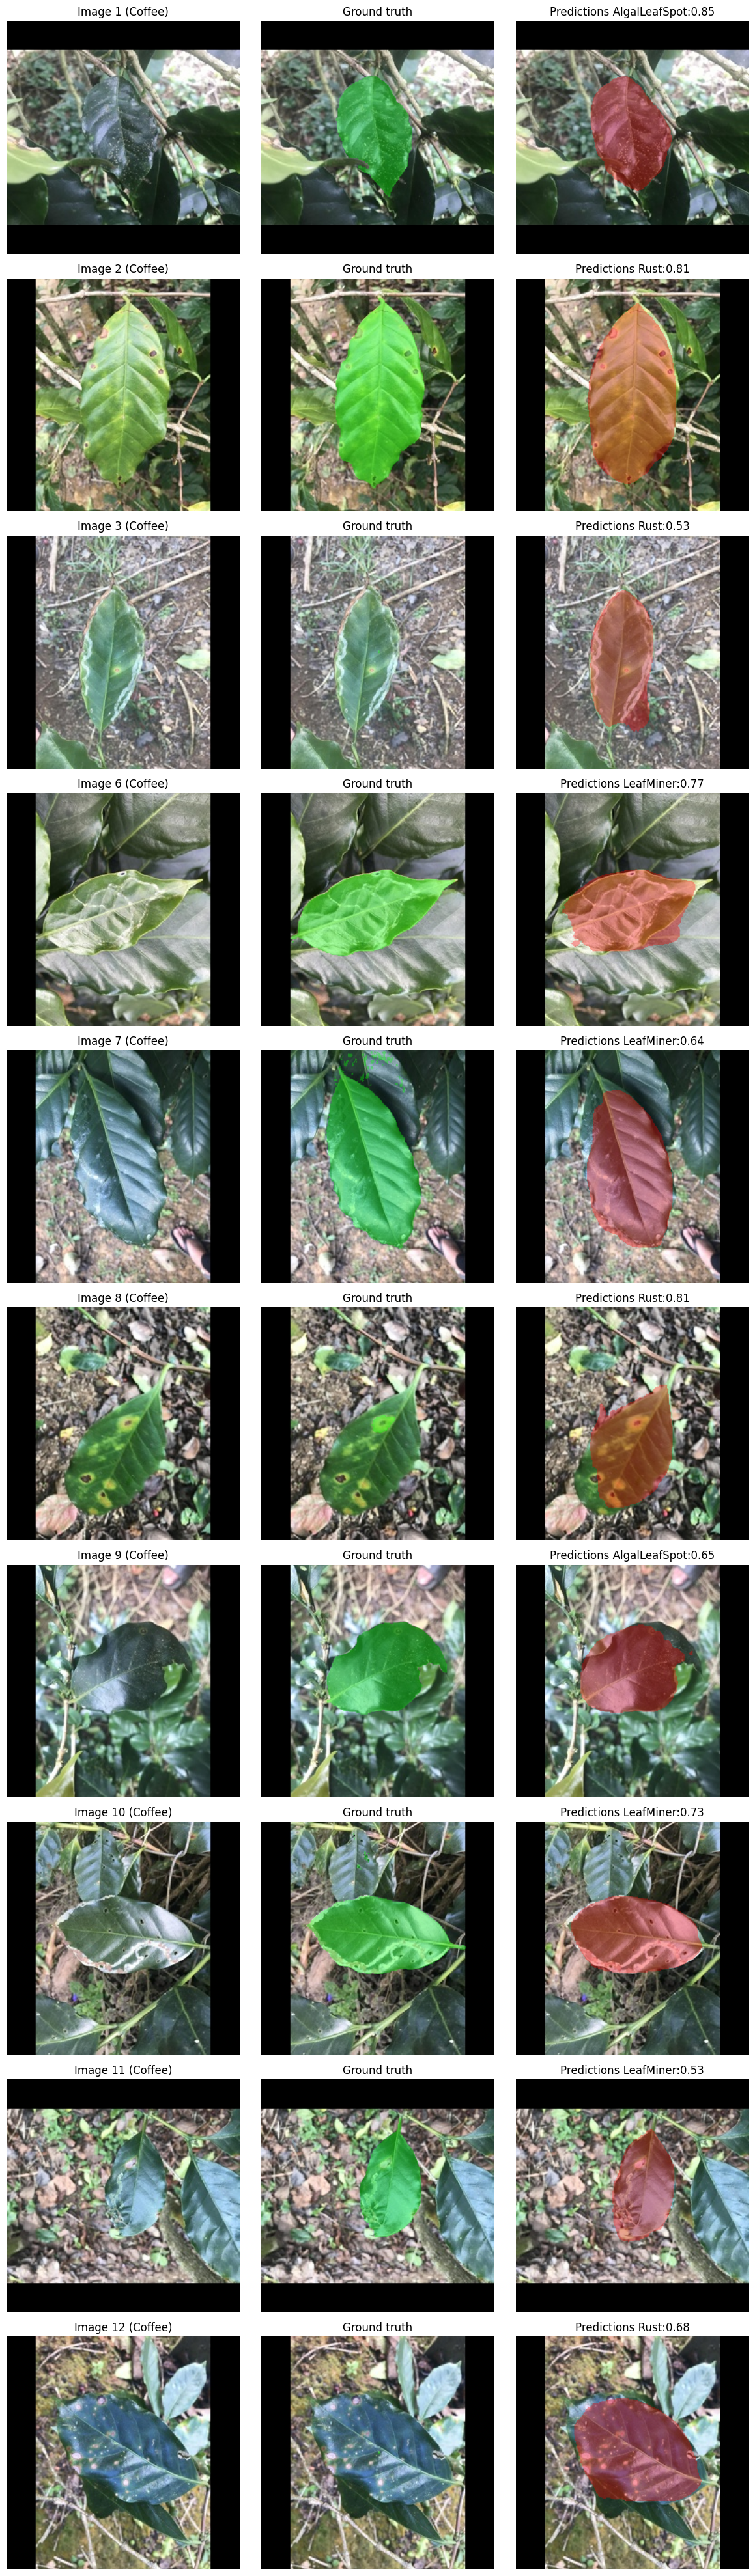

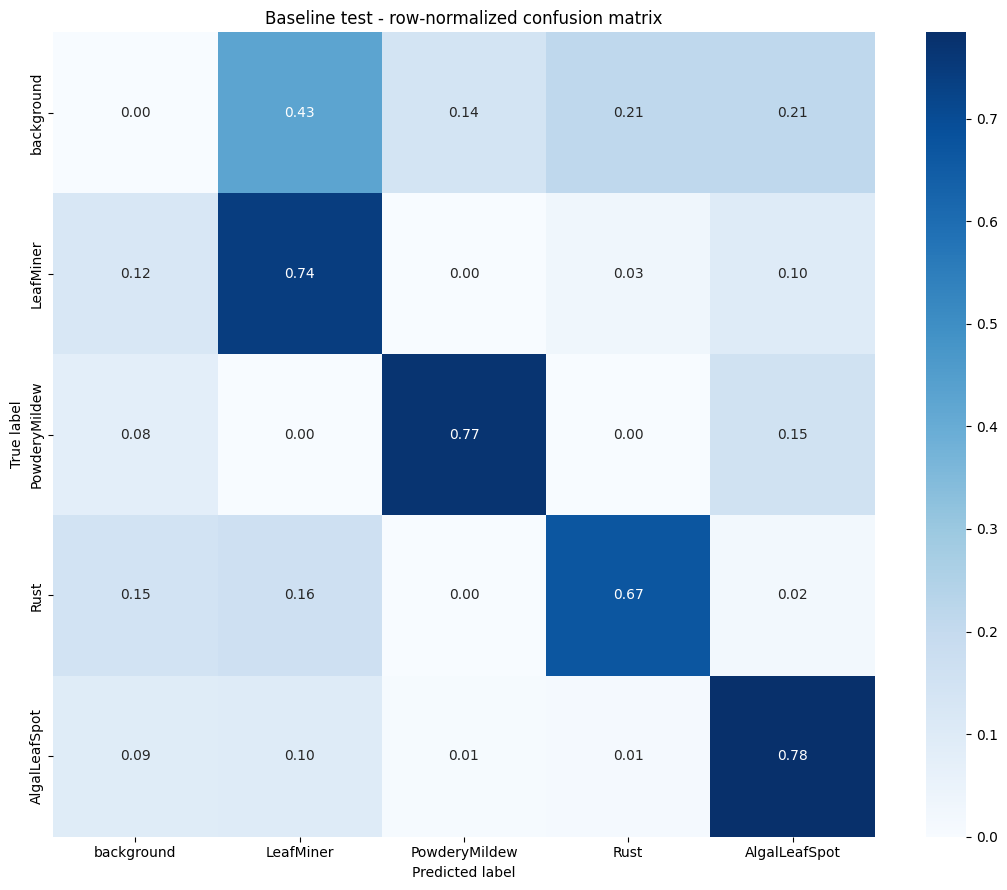

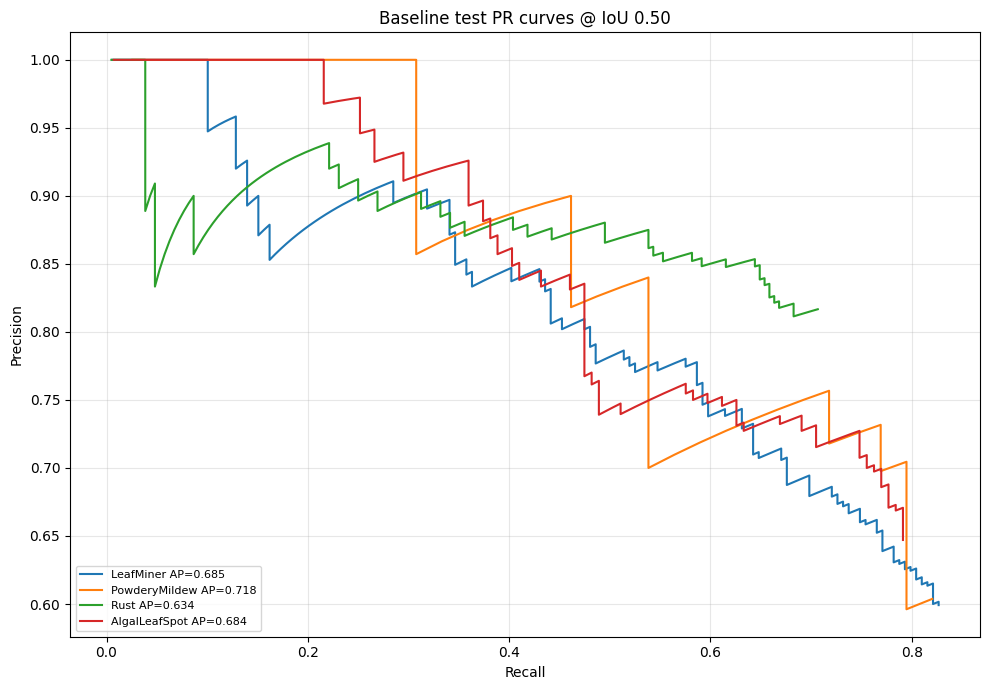

In [16]:
if CFG.run_training:
    baseline_model, baseline_checkpoint = load_model_from_checkpoint(baseline_best_path, DEVICE)
    baseline_val_records = collect_predictions(baseline_model, val_loader, CFG.score_threshold, max_images=CFG.max_eval_images)
    baseline_test_records = collect_predictions(baseline_model, test_loader, CFG.score_threshold, max_images=CFG.max_eval_images)

    baseline_val_metrics, baseline_val_ap, baseline_val_cm, baseline_val_cm_norm = evaluate_records(baseline_val_records, "val")
    baseline_test_metrics, baseline_test_ap, baseline_test_cm, baseline_test_cm_norm = evaluate_records(baseline_test_records, "test")
    baseline_domain_metrics = evaluate_by_domain(baseline_test_records, "test")

    print("Baseline validation metrics")
    display(pd.DataFrame([baseline_val_metrics])) if display else print(baseline_val_metrics)
    print("Baseline test metrics")
    display(pd.DataFrame([baseline_test_metrics])) if display else print(baseline_test_metrics)
    print("Baseline per-domain test metrics")
    display(baseline_domain_metrics) if display else print(baseline_domain_metrics)

    plot_prediction_examples(baseline_test_records, n=10, title="Baseline Mask R-CNN")
    plot_confusion_heatmap(baseline_test_cm_norm, "Baseline test")
    plot_pr_curves(baseline_test_ap, "Baseline test", iou_threshold=0.5)
else:
    baseline_test_metrics = {}
    baseline_domain_metrics = pd.DataFrame()
    baseline_test_records = []

## Section 17/20 - Error Analysis

Failures are grouped by the four proposal categories: visual similarity, low-quality images, complex compositions, and healthy-vs-early-disease confusion.


In [17]:
ERROR_GROUPS = {
    "AlgalLeafSpot_vs_Rust": (NAME_TO_MODEL_ID["AlgalLeafSpot"], NAME_TO_MODEL_ID["Rust"]),
    "PowderyMildew_vs_Rust": (NAME_TO_MODEL_ID["PowderyMildew"], NAME_TO_MODEL_ID["Rust"]),
    "LeafMiner_vs_AlgalLeafSpot": (NAME_TO_MODEL_ID["LeafMiner"], NAME_TO_MODEL_ID["AlgalLeafSpot"]),
}


def error_rows(records, iou_threshold: float = 0.5) -> pd.DataFrame:
    rows = []
    for rec in records:
        preds = sorted(rec["pred"], key=lambda item: item["score"], reverse=True)
        for gt in rec["gt"]:
            best = None
            best_iou = 0.0
            for pred in preds:
                iou = mask_iou(gt["mask"], pred["mask"])
                if iou > best_iou:
                    best_iou = iou
                    best = pred
            true_name = MODEL_ID_TO_NAME[gt["label"]]
            pred_name = MODEL_ID_TO_NAME[best["label"]] if best and best_iou >= iou_threshold else "background"
            if true_name != pred_name:
                rows.append({
                    "image_id": rec["image_id"],
                    "file_name": rec["file_name"],
                    "domain": rec["domain"],
                    "true": true_name,
                    "pred": pred_name,
                    "score": best["score"] if best else 0.0,
                    "iou": best_iou,
                    "group": assign_error_group(gt["label"], best["label"] if best and best_iou >= iou_threshold else 0, rec),
                })
    return pd.DataFrame(rows).sort_values(["group", "score"], ascending=[True, False]) if rows else pd.DataFrame(rows)


def assign_error_group(true_label: int, pred_label: int, record: dict[str, Any]) -> str:
    pair = (true_label, pred_label)
    pair_rev = (pred_label, true_label)
    for group_name, group_pair in ERROR_GROUPS.items():
        if pair == group_pair or pair_rev == group_pair:
            return group_name
    if len(record.get("gt", [])) >= 3:
        return "complex_compositions"
    return "low_quality_images_or_other"

if baseline_test_records:
    baseline_errors = error_rows(baseline_test_records)
    print("Baseline error analysis by group")
    display(baseline_errors.groupby("group").size().reset_index(name="count")) if display and not baseline_errors.empty else print(baseline_errors.groupby("group").size() if not baseline_errors.empty else baseline_errors)
    display(baseline_errors.head(30)) if display else print(baseline_errors.head(30))
else:
    baseline_errors = pd.DataFrame()


Baseline error analysis by group


,group,count
0,AlgalLeafSpot_vs_Rust,6
1,LeafMiner_vs_AlgalLeafSpot,32
2,low_quality_images_or_other,116


,image_id,file_name,domain,true,pred,score,iou,group
35,256,images/test/coffee/AlgalLeafSpot/coffee_000723...,Coffee,AlgalLeafSpot,Rust,0.754092,0.681097,AlgalLeafSpot_vs_Rust
149,1048,images/test/coffee/Rust/coffee_0005828.jpg,Coffee,Rust,AlgalLeafSpot,0.681262,0.914060,AlgalLeafSpot_vs_Rust
64,472,images/test/coffee/Rust/coffee_0005550.jpg,Coffee,Rust,AlgalLeafSpot,0.632952,0.912367,AlgalLeafSpot_vs_Rust
86,621,images/test/coffee/AlgalLeafSpot/coffee_000716...,Coffee,AlgalLeafSpot,Rust,0.624414,0.822118,AlgalLeafSpot_vs_Rust
34,254,images/test/coffee/Rust/coffee_0005719.jpg,Coffee,Rust,AlgalLeafSpot,0.598391,0.890915,AlgalLeafSpot_vs_Rust
22,153,images/test/coffee/Rust/coffee_0005825.jpg,Coffee,Rust,AlgalLeafSpot,0.547380,0.893860,AlgalLeafSpot_vs_Rust
153,1072,images/test/coffee/LeafMiner/coffee_0003480.jpg,Coffee,LeafMiner,AlgalLeafSpot,0.777780,0.882595,LeafMiner_vs_AlgalLeafSpot
19,121,images/test/coffee/LeafMiner/coffee_0004300.jpg,Coffee,LeafMiner,AlgalLeafSpot,0.732822,0.914648,LeafMiner_vs_AlgalLeafSpot
95,677,images/test/coffee/LeafMiner/coffee_0004103.jpg,Coffee,LeafMiner,AlgalLeafSpot,0.719232,0.869218,LeafMiner_vs_AlgalLeafSpot
12,66,images/test/coffee/AlgalLeafSpot/coffee_000694...,Coffee,AlgalLeafSpot,LeafMiner,0.700450,0.854438,LeafMiner_vs_AlgalLeafSpot


## Section 18/20 - Tuning Experiments

Tuning is separated from the baseline. Trial selection uses validation mAP@50:95 only; the test set remains locked until the best tuned checkpoint is selected.


In [18]:
TUNING_TRIALS = [
    {"run_name": "coffee_tuned_lr_1e4", "lr": 1e-4, "weight_decay": 2e-4, "effective_batch_size": 2, "cutmix": False, "mixup": False, "strong_aug": False},
    {"run_name": "coffee_tuned_lr_3e5", "lr": 3e-5, "weight_decay": 2e-4, "effective_batch_size": 2, "cutmix": False, "mixup": False, "strong_aug": False},
    {"run_name": "coffee_tuned_cutmix", "lr": 5e-5, "weight_decay": 2e-4, "effective_batch_size": 4, "cutmix": True, "mixup": False, "strong_aug": True},
    {"run_name": "coffee_tuned_frozen_bb", "lr": 5e-5, "weight_decay": 2e-4, "effective_batch_size": 2, "cutmix": True, "mixup": False, "strong_aug": False, "freeze_backbone_epochs": 5},
]

if CFG.run_training and CFG.run_tuning:
    tuning_results = []
    tuned_paths = []
    for trial in TUNING_TRIALS:
        print("Running tuning trial:", trial)
        trial_transform = DetectionTransform(train=True, affine=True, intensity=True, strong=trial["strong_aug"])
        trial_train_dataset = CocoMaskDataset(SPLIT_JSONS["train"], PROCESSED_ROOT, transforms=trial_transform, split_name="train")
        trial_train_loader = DataLoader(
            trial_train_dataset,
            batch_size=CFG.batch_size,
            shuffle=True,
            num_workers=CFG.num_workers,
            pin_memory=torch.cuda.is_available(),
            collate_fn=collate_fn,
        )
        best_path, history = fit_model(
            run_name=trial["run_name"],
            train_loader=trial_train_loader,
            val_loader=val_loader,
            epochs=CFG.tuning_epochs,
            lr=trial["lr"],
            weight_decay=trial["weight_decay"],
            grad_accum_steps=max(1, trial["effective_batch_size"] // CFG.batch_size),
            cutmix=trial["cutmix"],
            mixup=trial["mixup"],
            freeze_backbone_epochs=trial.get("freeze_backbone_epochs", 0),
        )
        best_val = float(history["mAP@50:95"].max()) if not history.empty else -1.0
        tuned_paths.append(best_path)
        tuning_results.append({**trial, "best_path": str(best_path), "best_val_mAP@50:95": best_val})
        gc.collect()
        torch.cuda.empty_cache() if torch.cuda.is_available() else None
    tuning_results_df = pd.DataFrame(tuning_results).sort_values("best_val_mAP@50:95", ascending=False)
    display(tuning_results_df) if display else print(tuning_results_df)
    tuning_results_df.to_csv(CFG.output_dir / "tuning_results.csv", index=False)
    tuned_best_path = Path(tuning_results_df.iloc[0]["best_path"])
else:
    tuning_results_df = pd.DataFrame()
    tuned_best_path = resolve_tuned_best_path() if CFG.run_training else CFG.output_dir / "coffee_tuned_best.pth"
    print("Tuning skipped or training disabled. Using checkpoint:", tuned_best_path)


Running tuning trial: {'run_name': 'coffee_tuned_lr_1e4', 'lr': 0.0001, 'weight_decay': 0.0002, 'effective_batch_size': 2, 'cutmix': False, 'mixup': False, 'strong_aug': False}


epoch 1:   0%|          | 0/1320 [00:00<?, ?it/s]

collect predictions:   0%|          | 0/569 [00:00<?, ?it/s]

New best coffee_tuned_lr_1e4: epoch=1, mAP@50:95=0.2387


epoch 2:   0%|          | 0/1320 [00:00<?, ?it/s]

...

epoch 9:   0%|          | 0/1320 [00:00<?, ?it/s]

collect predictions:   0%|          | 0/569 [00:00<?, ?it/s]

epoch 10:   0%|          | 0/1320 [00:00<?, ?it/s]

collect predictions:   0%|          | 0/569 [00:00<?, ?it/s]

,run_name,lr,weight_decay,effective_batch_size,cutmix,mixup,strong_aug,best_path,best_val_mAP@50:95,freeze_backbone_epochs
3,coffee_tuned_frozen_bb,0.00005,0.0002,2,True,False,False,/kaggle/working/mask_rcnn_runs/coffee_tuned_fr...,0.581304,5.0
2,coffee_tuned_cutmix,0.00005,0.0002,4,True,False,True,/kaggle/working/mask_rcnn_runs/coffee_tuned_cu...,0.485371,NaN
1,coffee_tuned_lr_3e5,0.00003,0.0002,2,False,False,False,/kaggle/working/mask_rcnn_runs/coffee_tuned_lr...,0.459851,NaN
0,coffee_tuned_lr_1e4,0.00010,0.0002,2,False,False,False,/kaggle/working/mask_rcnn_runs/coffee_tuned_lr...,0.402749,NaN


## Section 19/20 - Tuned Model Evaluation, CPU Benchmark, And Export

The selected tuned checkpoint is evaluated on the locked test set. The export package contains the required 5 HuggingFace files and uses Kaggle Secrets for tokens.


Using tuned checkpoint for final evaluation/export: /kaggle/working/mask_rcnn_runs/coffee_tuned_frozen_bb_best.pth


collect predictions:   0%|          | 0/565 [00:00<?, ?it/s]

CPU benchmark:   0%|          | 0/100 [00:00<?, ?it/s]

Tuned test metrics


,split,mAP@50:95,mAP@50,Macro F1,Weighted F1,Accuracy,mIoU,Dice,cpu_ms_per_image_mean,cpu_ms_per_image_std,cpu_ms_per_image_median,cpu_throughput_img_s,model_size_mb
0,test,0.591939,0.798665,0.642726,0.671542,0.692308,0.770262,0.8236,586.494149,35.523008,581.378487,1.705047,503.439048


Tuned per-domain metrics


,split,mAP@50:95,mAP@50,Macro F1,Weighted F1,Accuracy,mIoU,Dice,domain
0,test_coffee,0.591939,0.798665,0.642726,0.671542,0.692308,0.770262,0.8236,Coffee


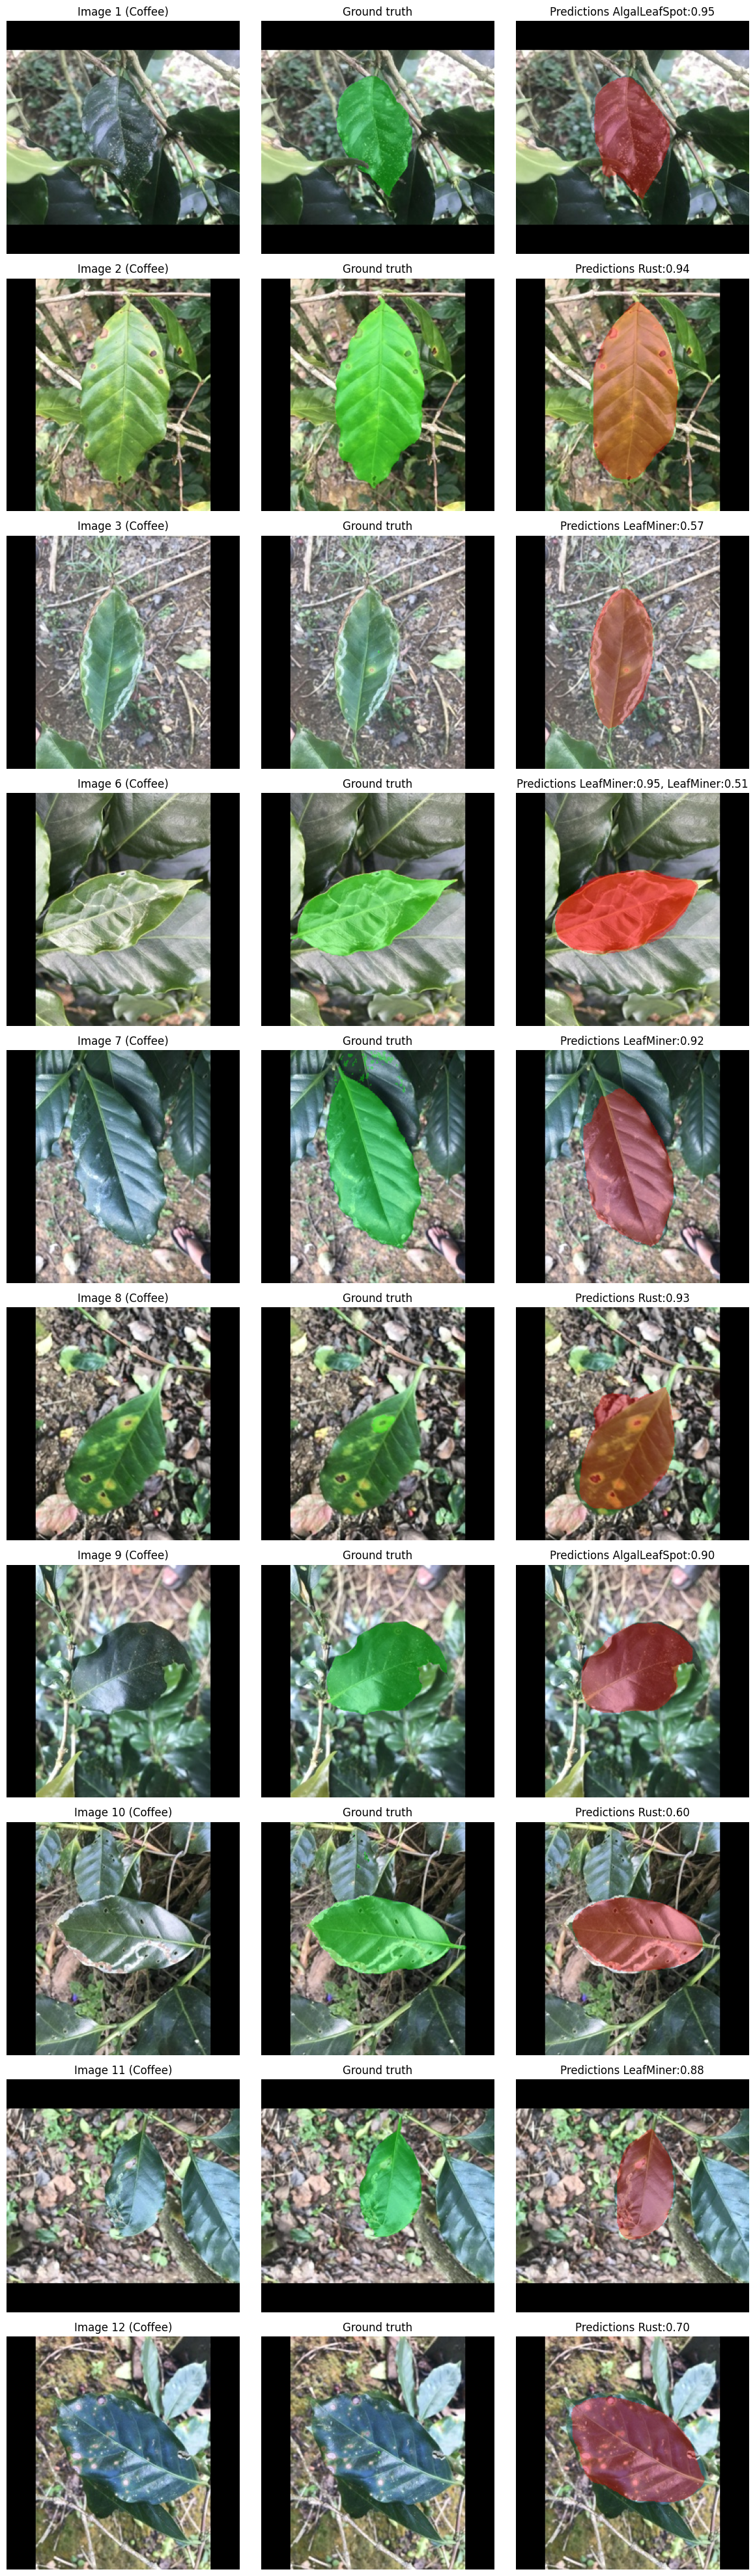

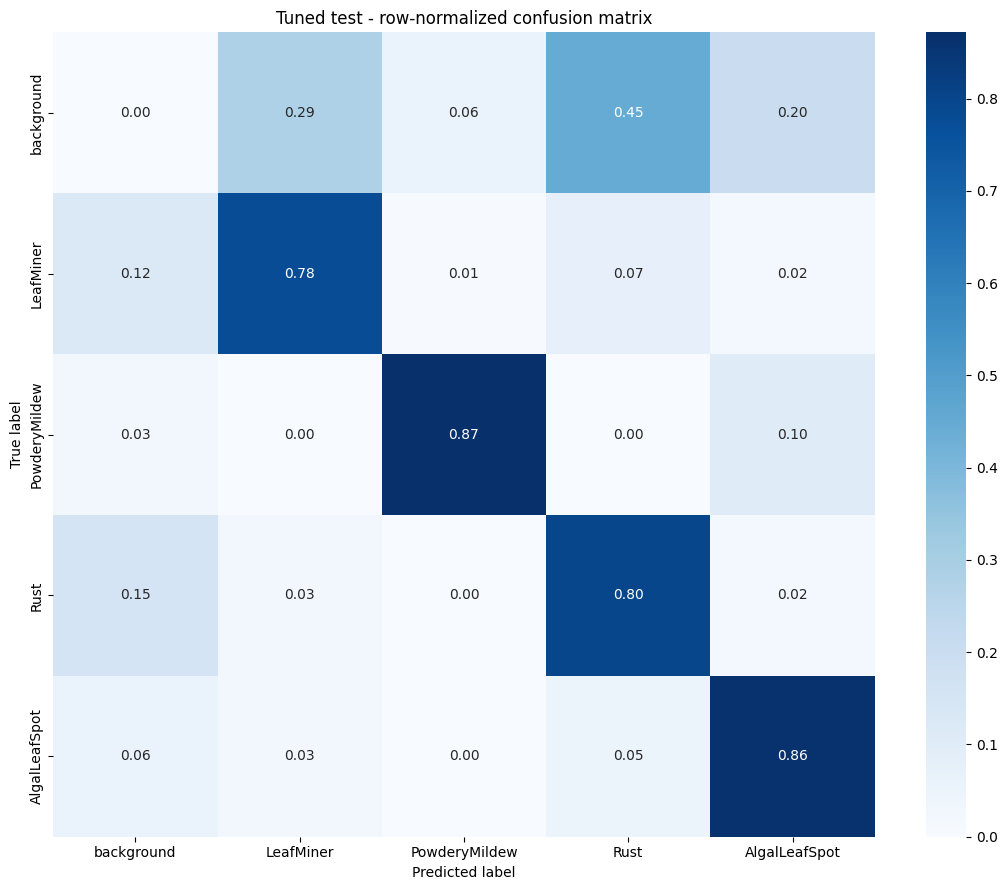

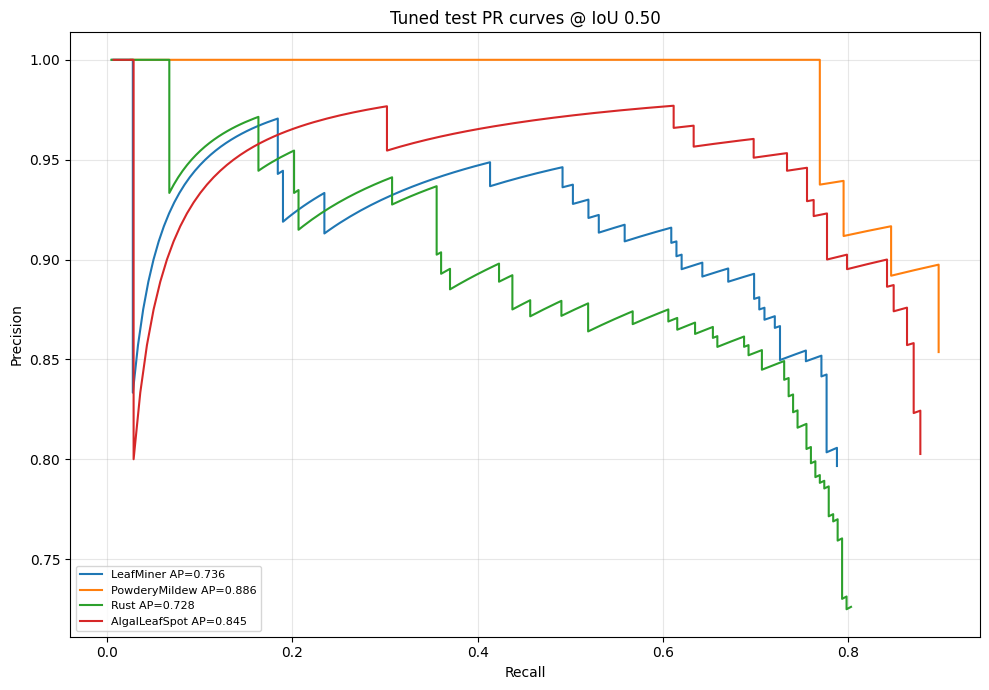

HuggingFace export package ready: /kaggle/working/hf_export


In [19]:
def benchmark_cpu_inference(checkpoint_path: Path, dataset: Dataset, n_images: int, warmup: int):
    cpu_model, _ = load_model_from_checkpoint(checkpoint_path, map_location=torch.device("cpu"))
    cpu_model.eval()
    samples = [dataset[i][0] for i in range(min(len(dataset), n_images + warmup))]
    with torch.inference_mode():
        for image in samples[:warmup]:
            _ = cpu_model([image.cpu()])
        times = []
        for image in tqdm(samples[warmup:], desc="CPU benchmark"):
            start = time.perf_counter()
            _ = cpu_model([image.cpu()])
            times.append(time.perf_counter() - start)
    ms = np.asarray(times) * 1000.0
    return {
        "cpu_ms_per_image_mean": float(ms.mean()) if len(ms) else float("nan"),
        "cpu_ms_per_image_std": float(ms.std()) if len(ms) else float("nan"),
        "cpu_ms_per_image_median": float(np.median(ms)) if len(ms) else float("nan"),
        "cpu_throughput_img_s": float(1000.0 / ms.mean()) if len(ms) and ms.mean() > 0 else float("nan"),
    }


def package_for_hf(checkpoint_path: Path, final_metrics: dict[str, Any], cpu_metrics: dict[str, Any], export_dir: Path):
    export_dir.mkdir(parents=True, exist_ok=True)
    shutil.copy2(checkpoint_path, export_dir / "pytorch_model.pth")
    (export_dir / "class_names.json").write_text(json.dumps(CLASS_NAMES, indent=2), encoding="utf-8")
    (export_dir / "normalization_stats.json").write_text(json.dumps(NORMALIZATION_STATS, indent=2), encoding="utf-8")
    config = {
        "architecture": "Mask R-CNN ResNet50-FPN",
        "library": "torchvision.models.detection",
        "weights": "DEFAULT COCO-pretrained",
        "input_size": [CFG.input_size, CFG.input_size],
        "num_project_classes": NUM_PROJECT_CLASSES,
        "num_model_classes": NUM_MODEL_CLASSES,
        "class_names": CLASS_NAMES,
        "seed": CFG.seed,
        "normalization_stats": NORMALIZATION_STATS,
        "metrics": final_metrics,
        "cpu_metrics": cpu_metrics,
        "checkpoint_path": str(checkpoint_path),
        "hf_repo_id": CFG.hf_repo_id,
    }
    (export_dir / "config.json").write_text(json.dumps(config, indent=2), encoding="utf-8")
    model_card = f"""# Mask R-CNN ResNet50-FPN — Coffee Disease Model\n\nCoffee-specific Mask R-CNN for Vietnam plant disease instance segmentation.\n\n- Architecture: Mask R-CNN ResNet50-FPN\n- Library: torchvision.models.detection\n- Weights: DEFAULT COCO-pretrained\n- Input size: {CFG.input_size}x{CFG.input_size}\n- Classes: {', '.join(CLASS_NAMES)}\n- Seed: {CFG.seed}\n\n## Metrics\n\n```json\n{json.dumps(final_metrics, indent=2)}\n```\n\n## CPU Performance\n\n```json\n{json.dumps(cpu_metrics, indent=2)}\n```\n\n## Known Error Groups\n\n1. Visual similarity between diseases.\n2. Low-quality images such as blur and poor lighting.\n3. Complex compositions with multiple leaves or occlusion.\n4. Healthy vs early-stage disease confusion.\n"""
    (export_dir / "README.md").write_text(model_card, encoding="utf-8")
    manifest = {
        "files": ["pytorch_model.pth", "config.json", "class_names.json", "normalization_stats.json", "README.md"],
        "checkpoint_path": str(checkpoint_path),
        "hf_repo_id": CFG.hf_repo_id,
    }
    (export_dir / "export_manifest.json").write_text(json.dumps(manifest, indent=2), encoding="utf-8")
    required = ["pytorch_model.pth", "config.json", "class_names.json", "normalization_stats.json", "README.md", "export_manifest.json"]
    missing = [name for name in required if not (export_dir / name).exists()]
    if missing:
        raise AssertionError(f"HF export package missing files: {missing}")
    return export_dir

if CFG.run_training:
    tuned_best_path = resolve_tuned_best_path()
    print("Using tuned checkpoint for final evaluation/export:", tuned_best_path)
    tuned_model, tuned_checkpoint = load_model_from_checkpoint(tuned_best_path, DEVICE)
    tuned_test_records = collect_predictions(tuned_model, test_loader, CFG.score_threshold, max_images=CFG.max_eval_images)
    tuned_test_metrics, tuned_test_ap, tuned_test_cm, tuned_test_cm_norm = evaluate_records(tuned_test_records, "test")
    tuned_domain_metrics = evaluate_by_domain(tuned_test_records, "test")
    cpu_metrics = benchmark_cpu_inference(tuned_best_path, test_dataset, CFG.cpu_benchmark_images, CFG.cpu_warmup_images)
    size_metrics = {"model_size_mb": tuned_best_path.stat().st_size / (1024 * 1024)}
    tuned_test_metrics.update(cpu_metrics)
    tuned_test_metrics.update(size_metrics)

    print("Tuned test metrics")
    display(pd.DataFrame([tuned_test_metrics])) if display else print(tuned_test_metrics)
    print("Tuned per-domain metrics")
    display(tuned_domain_metrics) if display else print(tuned_domain_metrics)
    plot_prediction_examples(tuned_test_records, n=10, title="Tuned Mask R-CNN")
    plot_confusion_heatmap(tuned_test_cm_norm, "Tuned test")
    plot_pr_curves(tuned_test_ap, "Tuned test", iou_threshold=0.5)

    hf_dir = package_for_hf(tuned_best_path, tuned_test_metrics, cpu_metrics, CFG.hf_export_dir)
    print("HuggingFace export package ready:", hf_dir)
else:
    tuned_test_metrics = {}
    tuned_domain_metrics = pd.DataFrame()
    cpu_metrics = {}
    hf_dir = CFG.hf_export_dir


In [20]:
# Optional upload. Do not hard-code tokens; use Kaggle Secrets with key HF_TOKEN.
required_hf_files = ["pytorch_model.pth", "config.json", "class_names.json", "normalization_stats.json", "README.md", "export_manifest.json"]
missing_hf_files = [name for name in required_hf_files if not (CFG.hf_export_dir / name).exists()]
if missing_hf_files:
    raise FileNotFoundError(f"Run Section 19 first. Missing HuggingFace export files: {missing_hf_files}")

if CFG.upload_to_hub:
    try:
        from huggingface_hub import HfApi
        from kaggle_secrets import UserSecretsClient

        token = UserSecretsClient().get_secret("HF_TOKEN")
        if not token:
            raise ValueError("Kaggle Secret HF_TOKEN is empty")
        api = HfApi(token=token)
        api.create_repo(repo_id=CFG.hf_repo_id, exist_ok=True, repo_type="model")
        api.upload_folder(folder_path=str(CFG.hf_export_dir), repo_id=CFG.hf_repo_id, repo_type="model")
        print("Uploaded to HuggingFace Hub:", CFG.hf_repo_id)
        print("Model URL:", f"https://huggingface.co/{CFG.hf_repo_id}")
    except Exception as exc:
        raise RuntimeError("HuggingFace upload failed. Check Kaggle Secret HF_TOKEN, token write permission, and repo id.") from exc
else:
    print("Upload skipped. Set CFG.upload_to_hub=True and configure Kaggle Secret HF_TOKEN to push artifacts.")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/hf_api.py:9786: UserWarning: Warnings while validating metadata in README.md:
- empty or missing yaml metadata in repo card
  warnings.warn(f"Warnings while validating metadata in README.md:\n{message}")


Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

Uploaded to HuggingFace Hub: trisleex/mask-rcnn-coffee-disease-model
Model URL: https://huggingface.co/trisleex/mask-rcnn-coffee-disease-model


## Section 20/20 - Pre-flight Verification And Final Comparison Table

This section enforces the requested verification rules before the notebook is considered complete.


In [21]:
def verify_preflight():
    checks = {}
    checks["seed_is_42"] = (SEED == 42 and CFG.seed == 42)
    checks["class_names_match_source"] = (CLASS_NAMES == EXPECTED_CLASS_NAMES)
    checks["uses_4_plus_background"] = (NUM_PROJECT_CLASSES == 4 and NUM_MODEL_CLASSES == 5)
    checks["input_size_256"] = (CFG.input_size == 256)
    checks["per_domain_eval_implemented"] = callable(evaluate_by_domain)
    checks["row_normalized_confusion_implemented"] = callable(plot_confusion_heatmap)
    if CFG.run_training:
        checks["baseline_checkpoint_exists"] = baseline_best_path.exists()
        checks["tuned_checkpoint_exists"] = Path(tuned_best_path).exists()
        checks["hf_required_files"] = all((CFG.hf_export_dir / name).exists() for name in [
            "pytorch_model.pth", "config.json", "class_names.json", "normalization_stats.json", "README.md", "export_manifest.json"
        ])
        checks["coffee_domain_reported"] = "Coffee" in tuned_domain_metrics.get("domain", []).values
    else:
        checks["baseline_checkpoint_exists"] = False
        checks["tuned_checkpoint_exists"] = False
        checks["hf_required_files"] = False
        checks["coffee_domain_reported"] = False
    failed = {name: ok for name, ok in checks.items() if not ok}
    print(json.dumps(checks, indent=2))
    if failed:
        raise AssertionError(f"Pre-flight verification failed: {failed}")
    return checks

if CFG.run_training:
    final_rows = []
    baseline_row = {"Config": "Baseline", **baseline_test_metrics}
    tuned_row = {"Config": "Tuned best", **tuned_test_metrics}
    final_rows.extend([baseline_row, tuned_row])
    final_comparison = pd.DataFrame(final_rows)
    wanted_cols = [
        "Config", "mAP@50", "mAP@50:95", "mIoU", "Dice", "Macro F1", "Weighted F1", "Accuracy",
        "cpu_ms_per_image_mean", "cpu_throughput_img_s", "model_size_mb",
    ]
    final_comparison = final_comparison[[col for col in wanted_cols if col in final_comparison.columns]]
    display(final_comparison) if display else print(final_comparison)
    final_comparison.to_csv(CFG.output_dir / "baseline_vs_tuned_comparison.csv", index=False)
    verify_preflight()
else:
    print("Pre-flight verification requiring artifacts is skipped because CFG.run_training=False.")


,Config,mAP@50,mAP@50:95,mIoU,Dice,Macro F1,Weighted F1,Accuracy,cpu_ms_per_image_mean,cpu_throughput_img_s,model_size_mb
0,Baseline,0.680218,0.422597,0.726384,0.792677,0.539717,0.534493,0.571627,NaN,NaN,NaN
1,Tuned best,0.798665,0.591939,0.770262,0.823600,0.642726,0.671542,0.692308,586.494149,1.705047,503.439048


{
  "seed_is_42": true,
  "class_names_match_source": true,
  "uses_4_plus_background": true,
  "input_size_256": true,
  "per_domain_eval_implemented": true,
  "row_normalized_confusion_implemented": true,
  "baseline_checkpoint_exists": true,
  "tuned_checkpoint_exists": true,
  "hf_required_files": true,
  "coffee_domain_reported": true
}


In [22]:
from pathlib import Path

print("Checkpoint files:")
for p in sorted(CFG.output_dir.glob("*.pth")):
    print(f"{p} - {p.stat().st_size / (1024 * 1024):.2f} MB")

print()
print("HuggingFace export files:")
for p in sorted(CFG.hf_export_dir.glob("*")):
    print(f"{p} - {p.stat().st_size / (1024 * 1024):.2f} MB")


Checkpoint files:
/kaggle/working/mask_rcnn_runs/coffee_tuned_cutmix_best.pth - 501.73 MB
/kaggle/working/mask_rcnn_runs/coffee_tuned_cutmix_last.pth - 501.73 MB
/kaggle/working/mask_rcnn_runs/coffee_tuned_frozen_bb_best.pth - 503.44 MB
/kaggle/working/mask_rcnn_runs/coffee_tuned_frozen_bb_last.pth - 503.44 MB
/kaggle/working/mask_rcnn_runs/coffee_tuned_lr_1e4_best.pth - 501.73 MB
/kaggle/working/mask_rcnn_runs/coffee_tuned_lr_1e4_last.pth - 501.73 MB
/kaggle/working/mask_rcnn_runs/coffee_tuned_lr_3e5_best.pth - 501.73 MB
/kaggle/working/mask_rcnn_runs/coffee_tuned_lr_3e5_last.pth - 501.73 MB
/kaggle/working/mask_rcnn_runs/mask_rcnn_coffee_baseline_best.pth - 501.73 MB
/kaggle/working/mask_rcnn_runs/mask_rcnn_coffee_baseline_last.pth - 501.73 MB

HuggingFace export files:
/kaggle/working/hf_export/README.md - 0.00 MB
/kaggle/working/hf_export/class_names.json - 0.00 MB
/kaggle/working/hf_export/config.json - 0.00 MB
/kaggle/working/hf_export/export_manifest.json - 0.00 MB
/kaggle/worki